## Training Validate and Tune a YOLO Model

This Jupyter Notebook shows how the different YOLO Models have been trained, Validatet and the Hyper Parameters can be tuned and is Structered as follows. With the focus on the Segmentation model for hyperbolas and the Object Detection for Hyperbolas. but some steps where done also for the segmentation Model for Reinforcement bars which will be noted in this notebook.

- Chapter 1: Train YOLO Model
- Chapter 2: Validate YOLO Model
- Chapter 3: Hyperparameter Tuning

In [2]:
#Setting Working directory
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *

## Chapter 1 Train Yolo Models

A this Point three Models have been trained.
- Object Detection Model for Hyperbolas
- Instance Segmentation for Hyperbolas
- Instance Segmentation for Reinforcement bars

But the focus les on the Object Detection Model for Hyperbolas and the Instance Segmentation Model for Hyperbolas.

So For the Intital Training the Method of Transfer Learning has been used. Transfer Leaarning is a technique which uses knowledge or a dataset from a task to improve model performance on another task or Dataset. Which in the case of this work means that a pretrained model was used for each Model and then trained with a custom dataset for the tasks which are mentioned above.

To train a YOLO model with the ultralytics library is really easy. There are just some things that are needed. first there is a annotated Dataset needed with the following structure. Since annotation was done with the help of Roboflow the structre can be exportet like this.

data/ \
├─ images/ \
│  ├─ train/ \
│  │  ├─ img001.png \
│  │  ├─ img002.png \
│  │  └─ ... \
│  ├─ val/ \
│  │  ├─ img101.png \
│  │  └─ ... \
│  └─ test/                   # optional \
│     ├─ img201.png \
│     └─ ... \
│ \
├─ labels/ \
│  ├─ train/ \
│  │  ├─ img001.txt \
│  │  ├─ img002.txt \
│  │  └─ ... \
│  ├─ val/ \
│  │  ├─ img101.txt \
│  │  └─ ... \
│  └─ test/                   # optional \
│     ├─ img201.txt \
│     └─ ... \
│
└─ data.yaml 

**The data.yaml is structured as follows**

path: C:/vscode/PAINDGPR/YOLO_Model \
train: data/images/train \
val: data/images/val \
test: data/images/test   # optional 

nc: 1 #Number of Labels \
names: ["hyperbola"] # Label Name \
task: segment # this is only for Segmentation Models 


#### Training Object Detection Model for Hyperbolas
This shows the code which has been used. I recommend not ti run it from Jupyter Notebook instead run the Script **training_Object_Detection.py**

In [ ]:
#Setting Working directory
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *

from ultralytics import YOLO

# Load pretrained Model
model = YOLO("yolo11n.pt")

# Train on Custom dataset
results = model.train(data=YOLO_MODEL_OD_YAML, epochs = 200, batch= 4, project="YOLO_Model_od", name="Hyperbola_od_v1")

#### Training Instance Segmentation Model for Hyperbolas and preparation for Segmentation reinforcement bars
This shows the code which has been used. Here it shows the example for the Hyperbolas but for the reinforcing bars its the nearly the just the paths are diffrent I recommend dont run in from Jupyter Notebook instead run the Script **training_Instance_Segmentation.py**. But before the Annotations from Roboflow need to be converted to a YOLO friendly format. This is done with the **convert_coco** from ultralytics. A class has been implemented which does this job.

The Raw Segmentations are at **Annotated_Data/SEG_RAW/YOLO_Segmentation_Hyperbola/{valid or train}**
For the Reinforcement Bars the is also a folder.


In [2]:
from Pipeline.Segmentation_converter import CocoConverter

In [3]:
# for Segmentation model with hyperbolas
converter_seg_h = CocoConverter(ANNOTATION_RAW_SEG_H_DIR,ANNOTATION_SEG_H_DIR)
converter_seg_h.run()

Annotations C:\vscode\PAINDGPR\Annotated_Data\SEG_RAW\YOLO_Segmentation_Hyperbola\train\_annotations.coco.json: 100% ━━━━━━━━━━━━ 20/20 634.6it/s 0.0s
COCO data converted successfully.
Results saved to C:\vscode\PAINDGPR\Annotated_Data\YOLO_Segmentation_Hyperbola\train
Annotations C:\vscode\PAINDGPR\Annotated_Data\SEG_RAW\YOLO_Segmentation_Hyperbola\valid\_annotations.coco.json: 100% ━━━━━━━━━━━━ 3/3 600.0it/s 0.0s
COCO data converted successfully.
Results saved to C:\vscode\PAINDGPR\Annotated_Data\YOLO_Segmentation_Hyperbola\valid


The converted Segmentations are saved to **Annotated_Data/YOLO_Segmentation_Hyperbola**
this also done for the reinforcement bars

**Note** that there still has to be work done manualy these are:
- creating empty Labels for the Pictures without Annotations
- copy the labels from **labels/annotations.coco** to **labels** 

After the steps beforehand the Model for Segmentation Hyperbola was trained with the script **training_instance_segmentation.py** the code lookslike the following below.
This was also made for the reinforcement bars with the script **training_instance_segementation_rb.py**

In [ ]:
#Setting Working directory
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *

from ultralytics import YOLO

#load pretrained model
model = YOLO("yolo11n-seg.pt")

#train on custom dataset
results = model.train(data=YOLO_MODEL_SEG_H_YAML,epochs = 200,batch=4 ,project="YOLO_Model_seg", name="Hyperbola_seg")

### Chapter 2 Validate Model

With YOLO, the trained model can be validated using the validation dataset. In principle, a completely new validation dataset could also be used. However, the data must be annotated, otherwise YOLO cannot compute validation metrics.

To demonstrate how the validation process works and how to interpret the resulting metrics, the same validation set used during training was applied here. As a result, the outcomes should  match with the results of validation in training. Due to time constraints, it was not possible to annotate an entirely new validation dataset. Nevertheless, the existing results are sufficient to illustrate the validation procedure and the interpretation of the metrics.

Validation is made in the following order
- Validation Object Detection
- Validation Segmentation Hyperbolas

The following metrics, taken directly from the results.csv file generated during training, provide insight into how well the model learns to detect objects and how precisely it generates segmentation masks:

**Detection Metrics (Bounding Boxes)**

- **box_loss**
Indicates how accurately the model predicts the bounding box coordinates. A lower value means the predicted boxes align more closely with the ground-truth annotations.

- **class_loss**
Measures the model’s ability to correctly classify objects. A small class loss suggests that objects are being assigned to the correct categories.

- **dfl_loss (Distribution Focal Loss)**
Reflects the precision of bounding box regression by evaluating how well the model predicts the distribution of offsets. Lower values indicate more precise localization.

**Segmentation Metric**

- **seg_loss (Mask Loss)**
Evaluates how well the predicted segmentation masks match the ground-truth masks. It combines binary cross-entropy and a dice-based component. A decreasing seg_loss indicates that the model learns to generate more accurate object shapes and mask boundaries.

**Performance Metrics(Detection and Segmentation)**

- **mAP50**
The mean Average Precision at an IoU threshold of 0.5. It represents how effectively the model detects objects with moderate overlap requirements.

- **mAP50-95**
The mean Average Precision across multiple IoU thresholds (from 0.5 to 0.95). This is the most comprehensive performance metric and shows how robust the model is across strict and lenient detection criteria. its not only a metric if something is detect but also how precise the detection is

**note on Iou (Intersection over Union)**: IoU quantifies how much the predicted box or mask overlaps with the ground-truth annotation.
It is used as a threshold to determine whether a prediction is considered correct.
Higher IoU thresholds demand more precise localization or mask alignment.


These metrics collectively provide a detailed picture of the model’s detection and segmentation performance and are essential for validating improvements throughout the training process.




For the validation part, which purely evaluates the model on the validation datasets, the following plots and metrics are analyzed. These plots are automatically generated by YOLO and stored under
**runs/<task_type>/val** (where task_type is either detect or segment).
The following metrics are used to assess the performance of the model in both object detection and instance segmentation:

**mAP50**
Measures the mean Average Precision at an IoU threshold of 0.5. It reflects how reliably the model can detect or segment objects with a moderate overlap requirement.

**mAP50–95**
The mean Average Precision across IoU thresholds from 0.50 to 0.95. This is the strictest and most comprehensive evaluation metric, as it measures not only whether an object was detected but also how precisely the predicted box or mask matches the ground truth.

**Precision-Confidence Curve**
Indicates how many of the model’s predictions are correct (low false-positive rate).
With respect to the confidence threshold

**Recall- Confidence Curve**
Indicates how many of the actual objects in an image are correctly detected or segmented (low false-negative rate). with respect to the confidence threshold

**Precision and Recall Curve**
Visualizes the trade-off between precision and recall across all confidence thresholds.
The area under this curve forms the basis for mAP.

**F1-Score**
The harmonic mean of Precision and Recall. It represents the balance between correctly identified objects and missed detections. with respect to the confidence

**Confusion Matrix**
Visualizes how well the individual classes are distinguished. It shows which classes are correctly predicted and which are frequently misclassified.

##### Validating Object Detection

First step is to Plot the metrics from the results.csv. here chosen because its an object Detection Model only the metrics available for Object Detection.

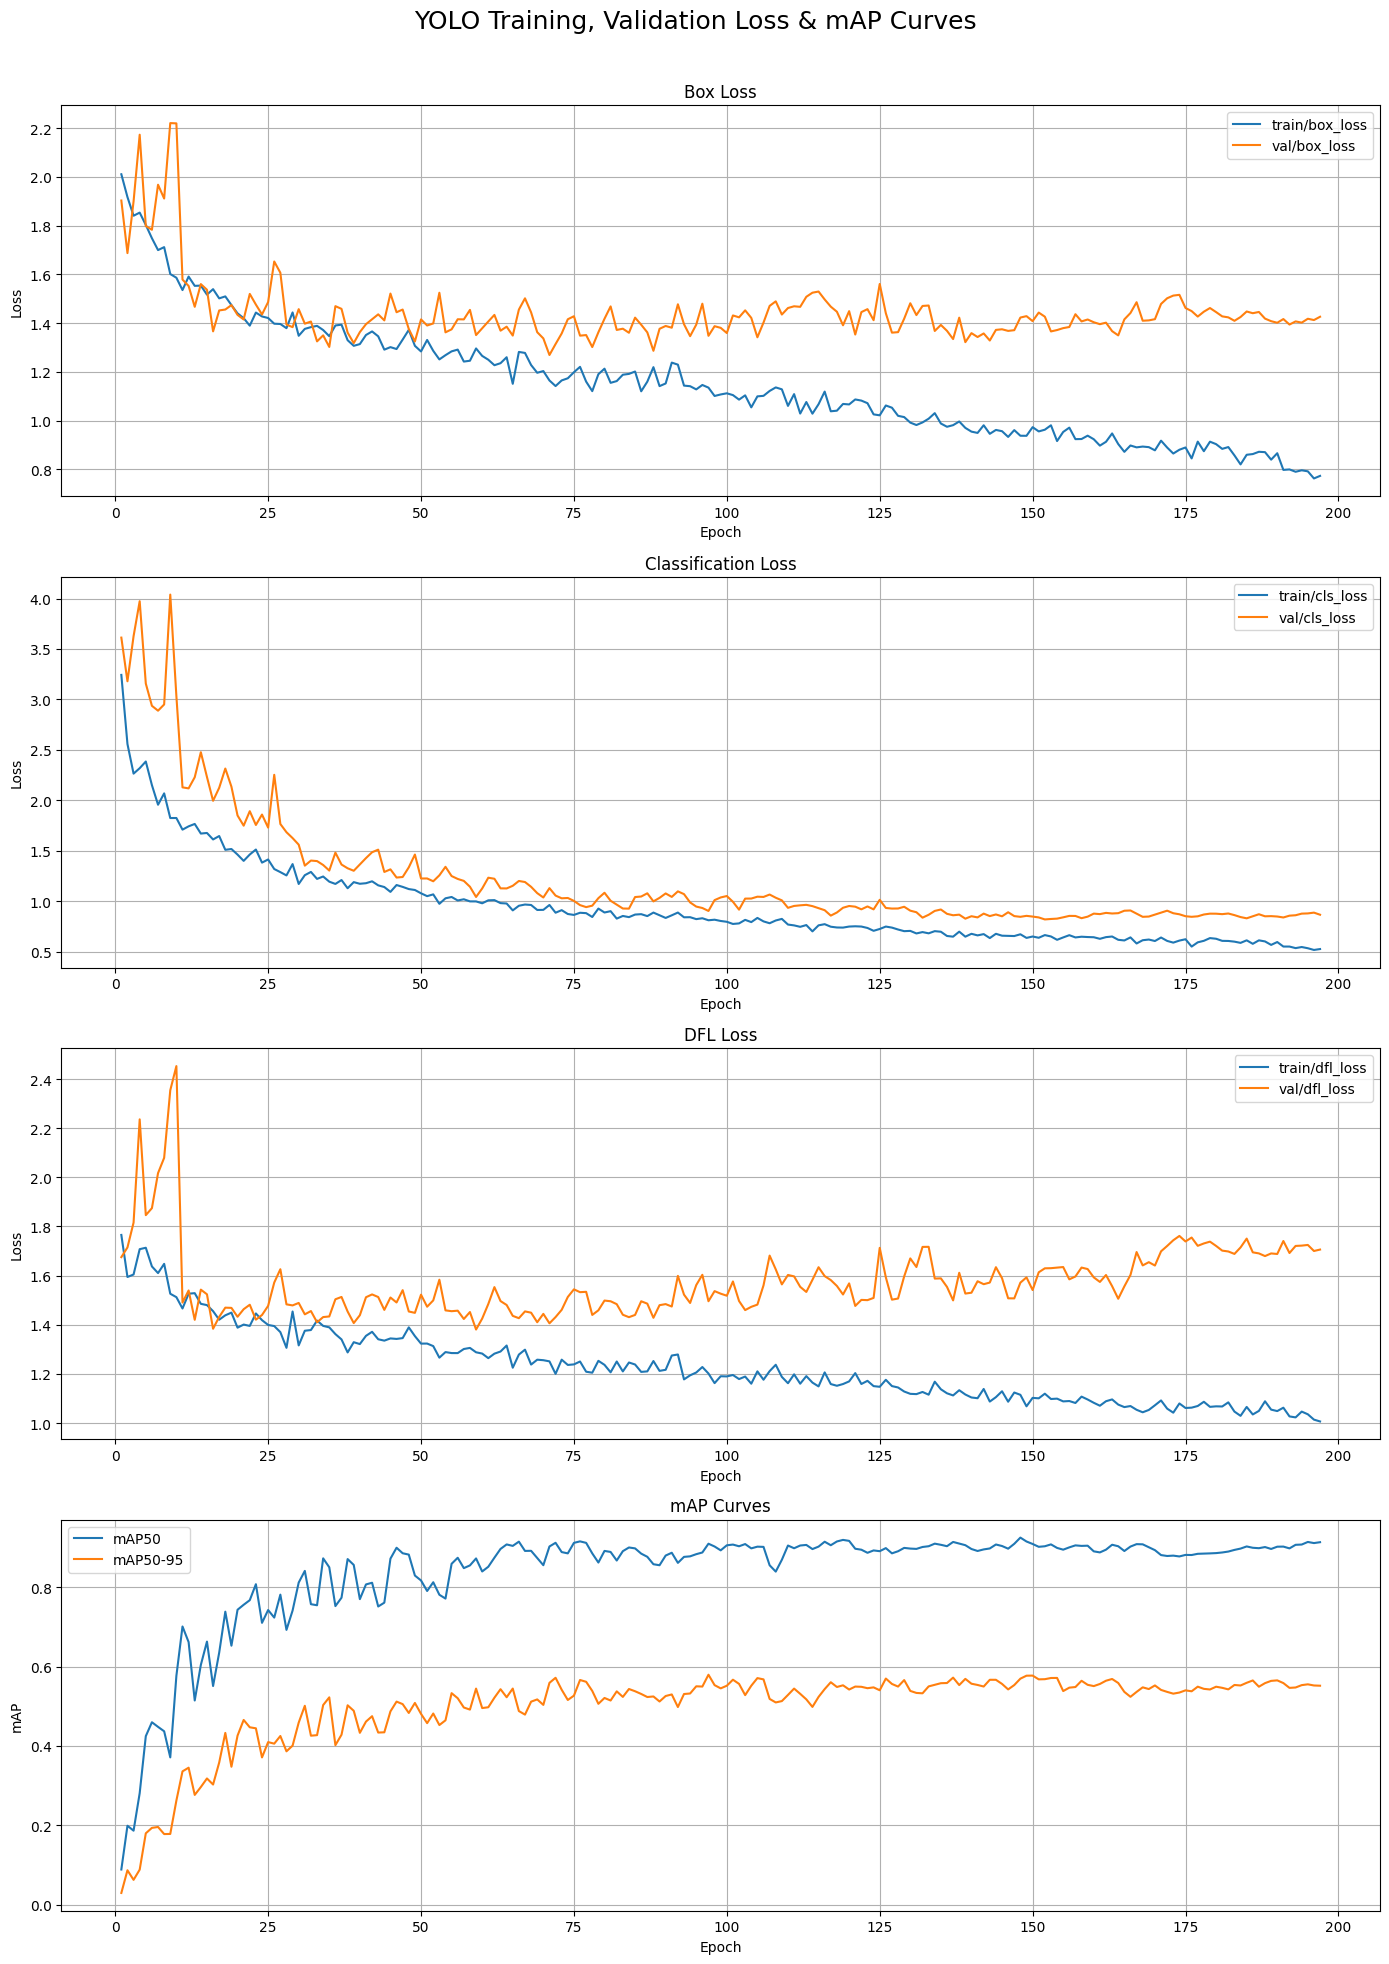

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV laden
df = pd.read_csv(BASE_DIR / "YOLO_model_od/Hyperbola_od_v13/results.csv")

# Plot-Größe
fig, axs = plt.subplots(4, 1, figsize=(14, 20))
fig.suptitle("YOLO Training, Validation Loss & mAP Curves", fontsize=18)

#box loss
axs[0].plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
axs[0].plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
axs[0].set_title("Box Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid()

#classification loss
axs[1].plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss")
axs[1].plot(df["epoch"], df["val/cls_loss"], label="val/cls_loss")
axs[1].set_title("Classification Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].legend()
axs[1].grid()

#dfl loss
axs[2].plot(df["epoch"], df["train/dfl_loss"], label="train/dfl_loss")
axs[2].plot(df["epoch"], df["val/dfl_loss"], label="val/dfl_loss")
axs[2].set_title("DFL Loss")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("Loss")
axs[2].legend()
axs[2].grid()

#map
axs[3].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axs[3].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axs[3].set_title("mAP Curves")
axs[3].set_xlabel("Epoch")
axs[3].set_ylabel("mAP")
axs[3].legend()
axs[3].grid()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Intepretation:

**box_loss**
- **train**: Over the course of the 200 training epochs, the training box loss decreases steadily. This indicates that the model continues to learn and improves its ability to accurately predict the bounding boxes of the hyperbolas. A lower box loss means that the predicted box coordinates align more closely with the ground-truth annotations
- **val**: In the early phase (approximately until epoch 50), the validation box loss also decreases, which suggests that the model initially generalizes well to unseen data. However, from around epoch 75 onward, the validation loss remains relatively constant and does not follow the downward trend of the training loss. This indicates that the weight updates in later epochs improve performance on the training data only, without contributing to better generalization. In other words, the model begins to overfit, as it no longer improves on the validation set.

**class_loss**
- **train**: here it is shown that over the 200 Epochs the train_loss is decreasing steadly which means the model learns how to correctly classify the objects.
- **val**: there is the same tendency seen for the validation set. So the updatet weight are working with respect to the class_loss for generalization.
But when put in to perspective its actually expectet since there is only one class

**dfl_loss**
- **train**: Again for the training the same as the other. But specific to dfl_loss it represents how the model learns the distribution of the bounding box positions. which in training seems to increase because the dfl_loss is decrasing.
- **val**: in the start it decrases but around the 50th epoch after that its increasing which is a tendency for overfitting.

**map50**: increases strongly and after around 75 Epochs its aoround the value 0.8. This means the model makes good predictions with respect to the iou threshold of 50.

**map50-95**: its the more strict value because it also represents as how precise a detections. so for the object detection model it also increases until the 75th epoch. After that the value sits around 0.5 which indicates that it can detect Hyperbolas but not thath precise.

In [8]:
#Validation Object Detection

from ultralytics import YOLO

#load model
model_od = YOLO(YOLO_MODEL_OD_DIR)

#validate model
metrics_od = model_od.val(data = YOLO_MODEL_OD_YAML)

Ultralytics 8.3.208  Python-3.11.13 torch-2.8.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 135.0113.5 MB/s, size: 78.9 KB)
val: Scanning C:\pythonad\PAINDHS25\PAINDGPR\Annotated_Data\YOLO_Object_Detection\valid\labels.cache... 37 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 37/37  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 0.9it/s 3.5s2.8s
                   all         37        102      0.773      0.882      0.908      0.583
Speed: 1.8ms preprocess, 73.4ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\pythonad\PAINDHS25\PAINDGPR\Notebooks\runs\detect\val


next step ist to get the most important metrics.

In [14]:
# looking at map 50 and map 50.95
print(f"map50: {metrics_od.box.map50}")
print(f"map50-95: {metrics_od.box.map}")

map50: 0.9080580714827375
map50-95: 0.5826695619423811


**mAP50**
is very high which means the model detects Objects with respect to IOU 50
**mAp50-95**
is lower than mAP50 but expected than it is a more strict metric which gives us intepretation of how precise the model ist but it seems like a pretty good value.

**Precision**

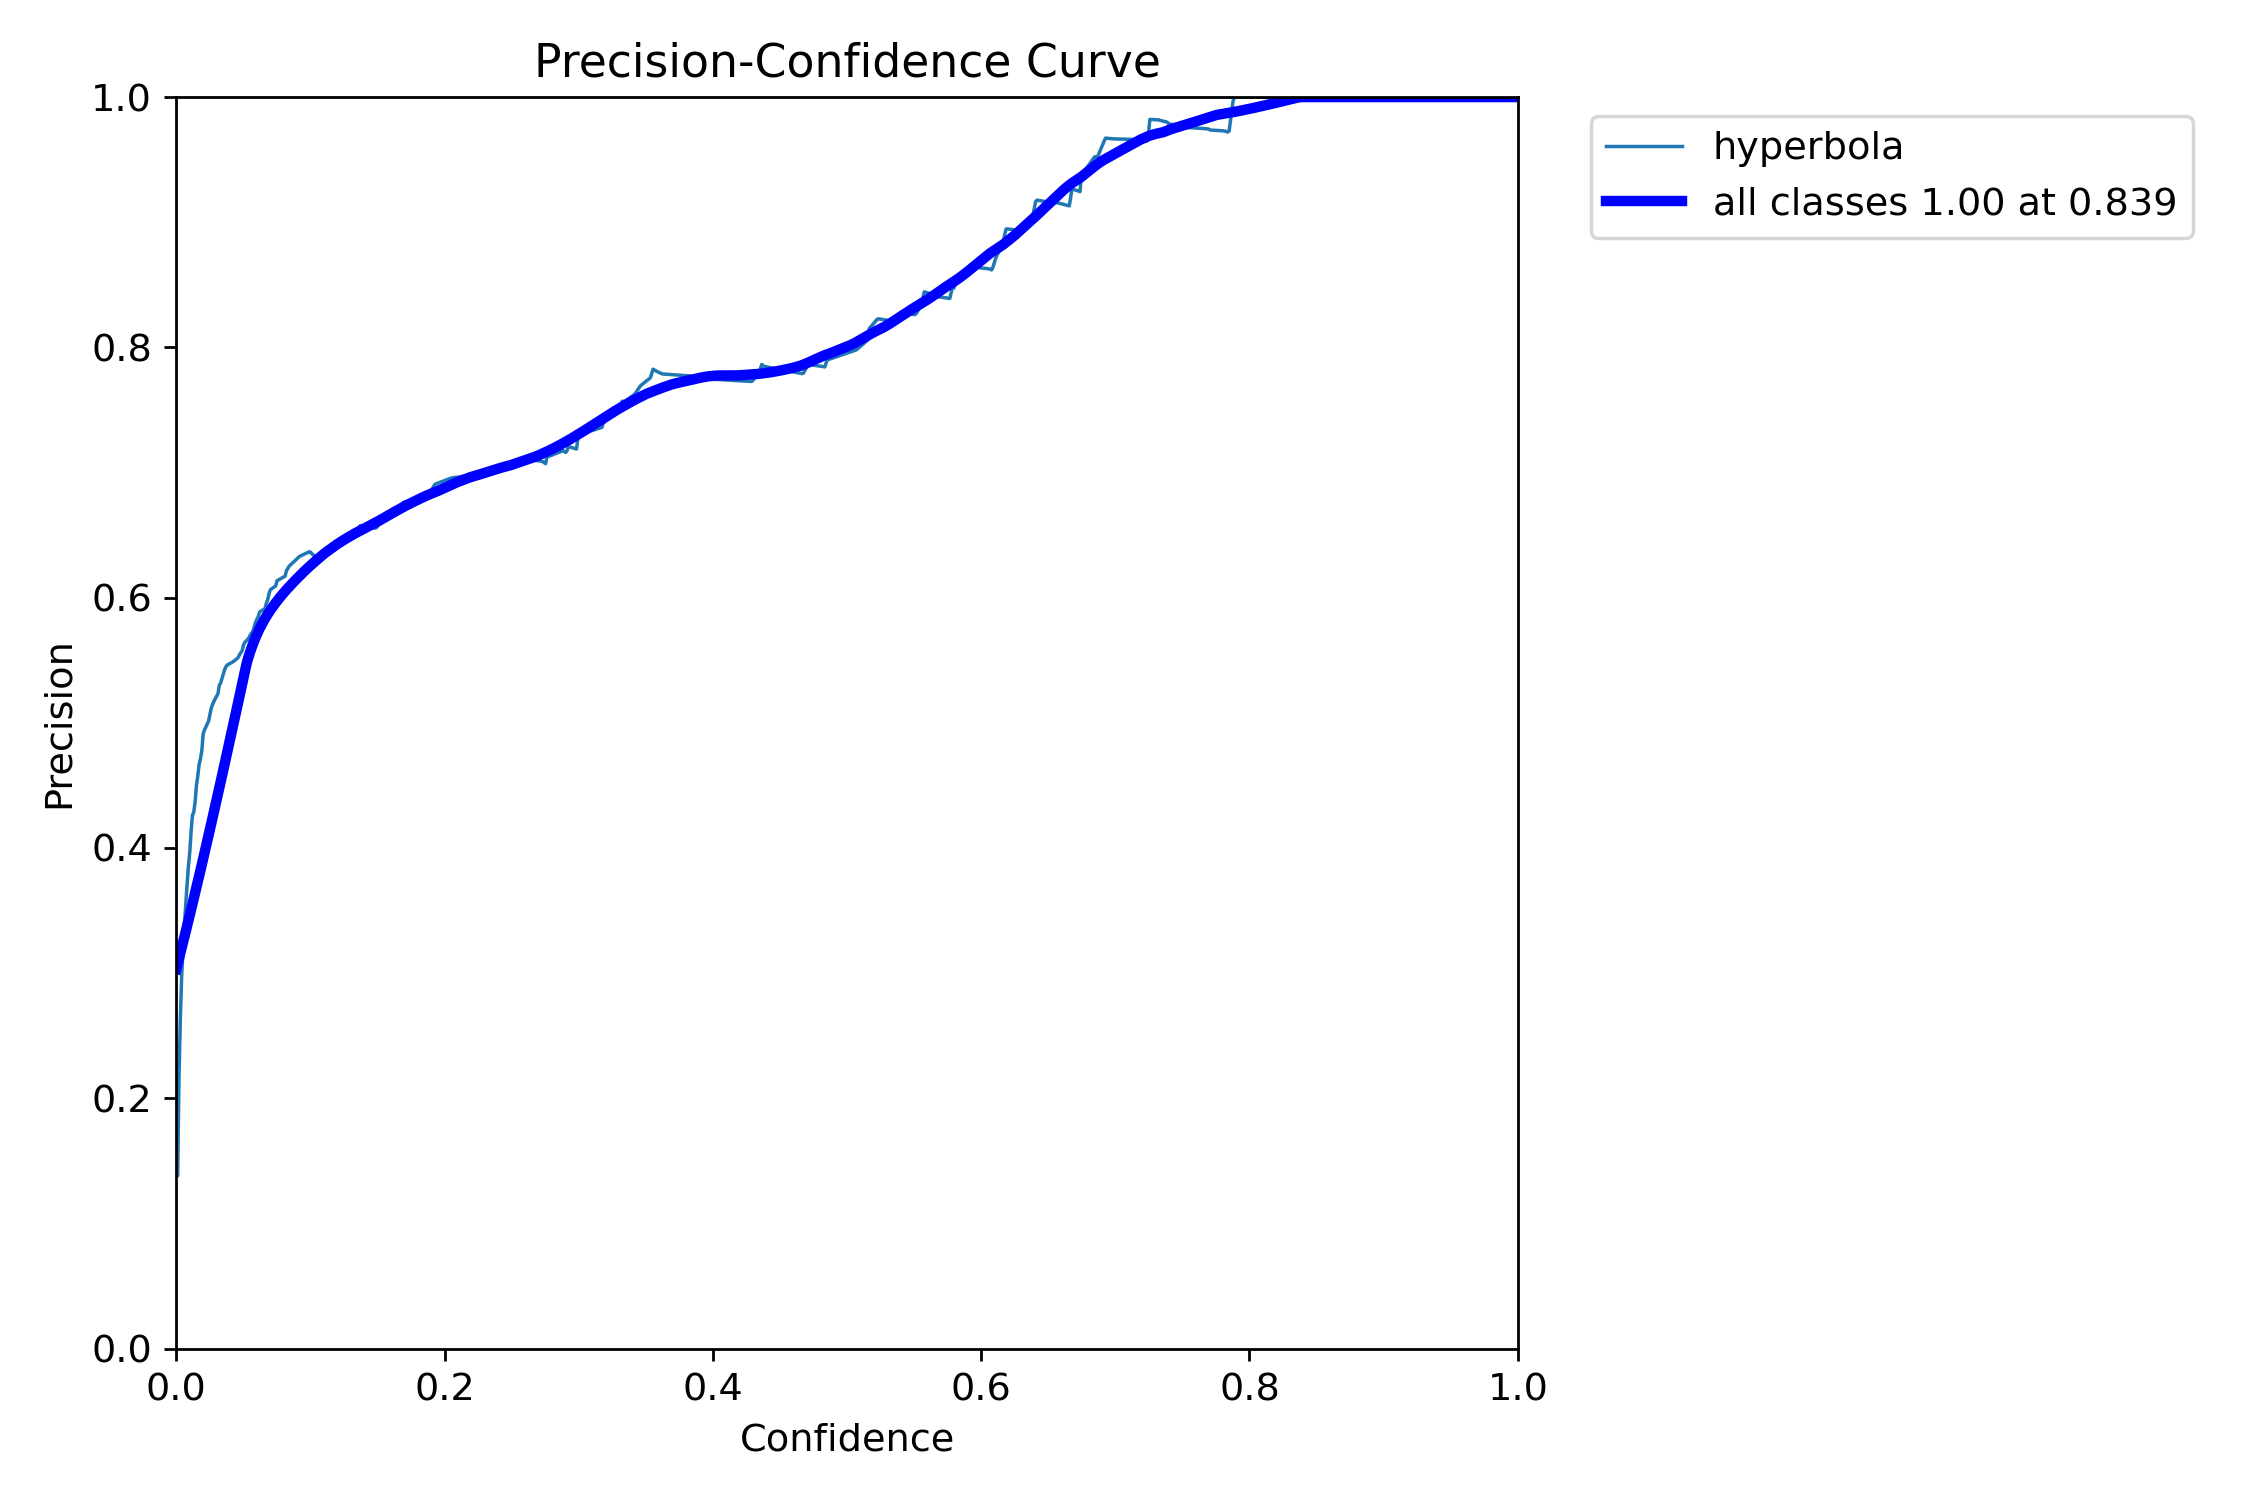

this show us the Precision with respect to the confidence threshold thath means how how many detectet Objects are really correct it looks normal because its increasing with a higher value for the confidence.

Recall

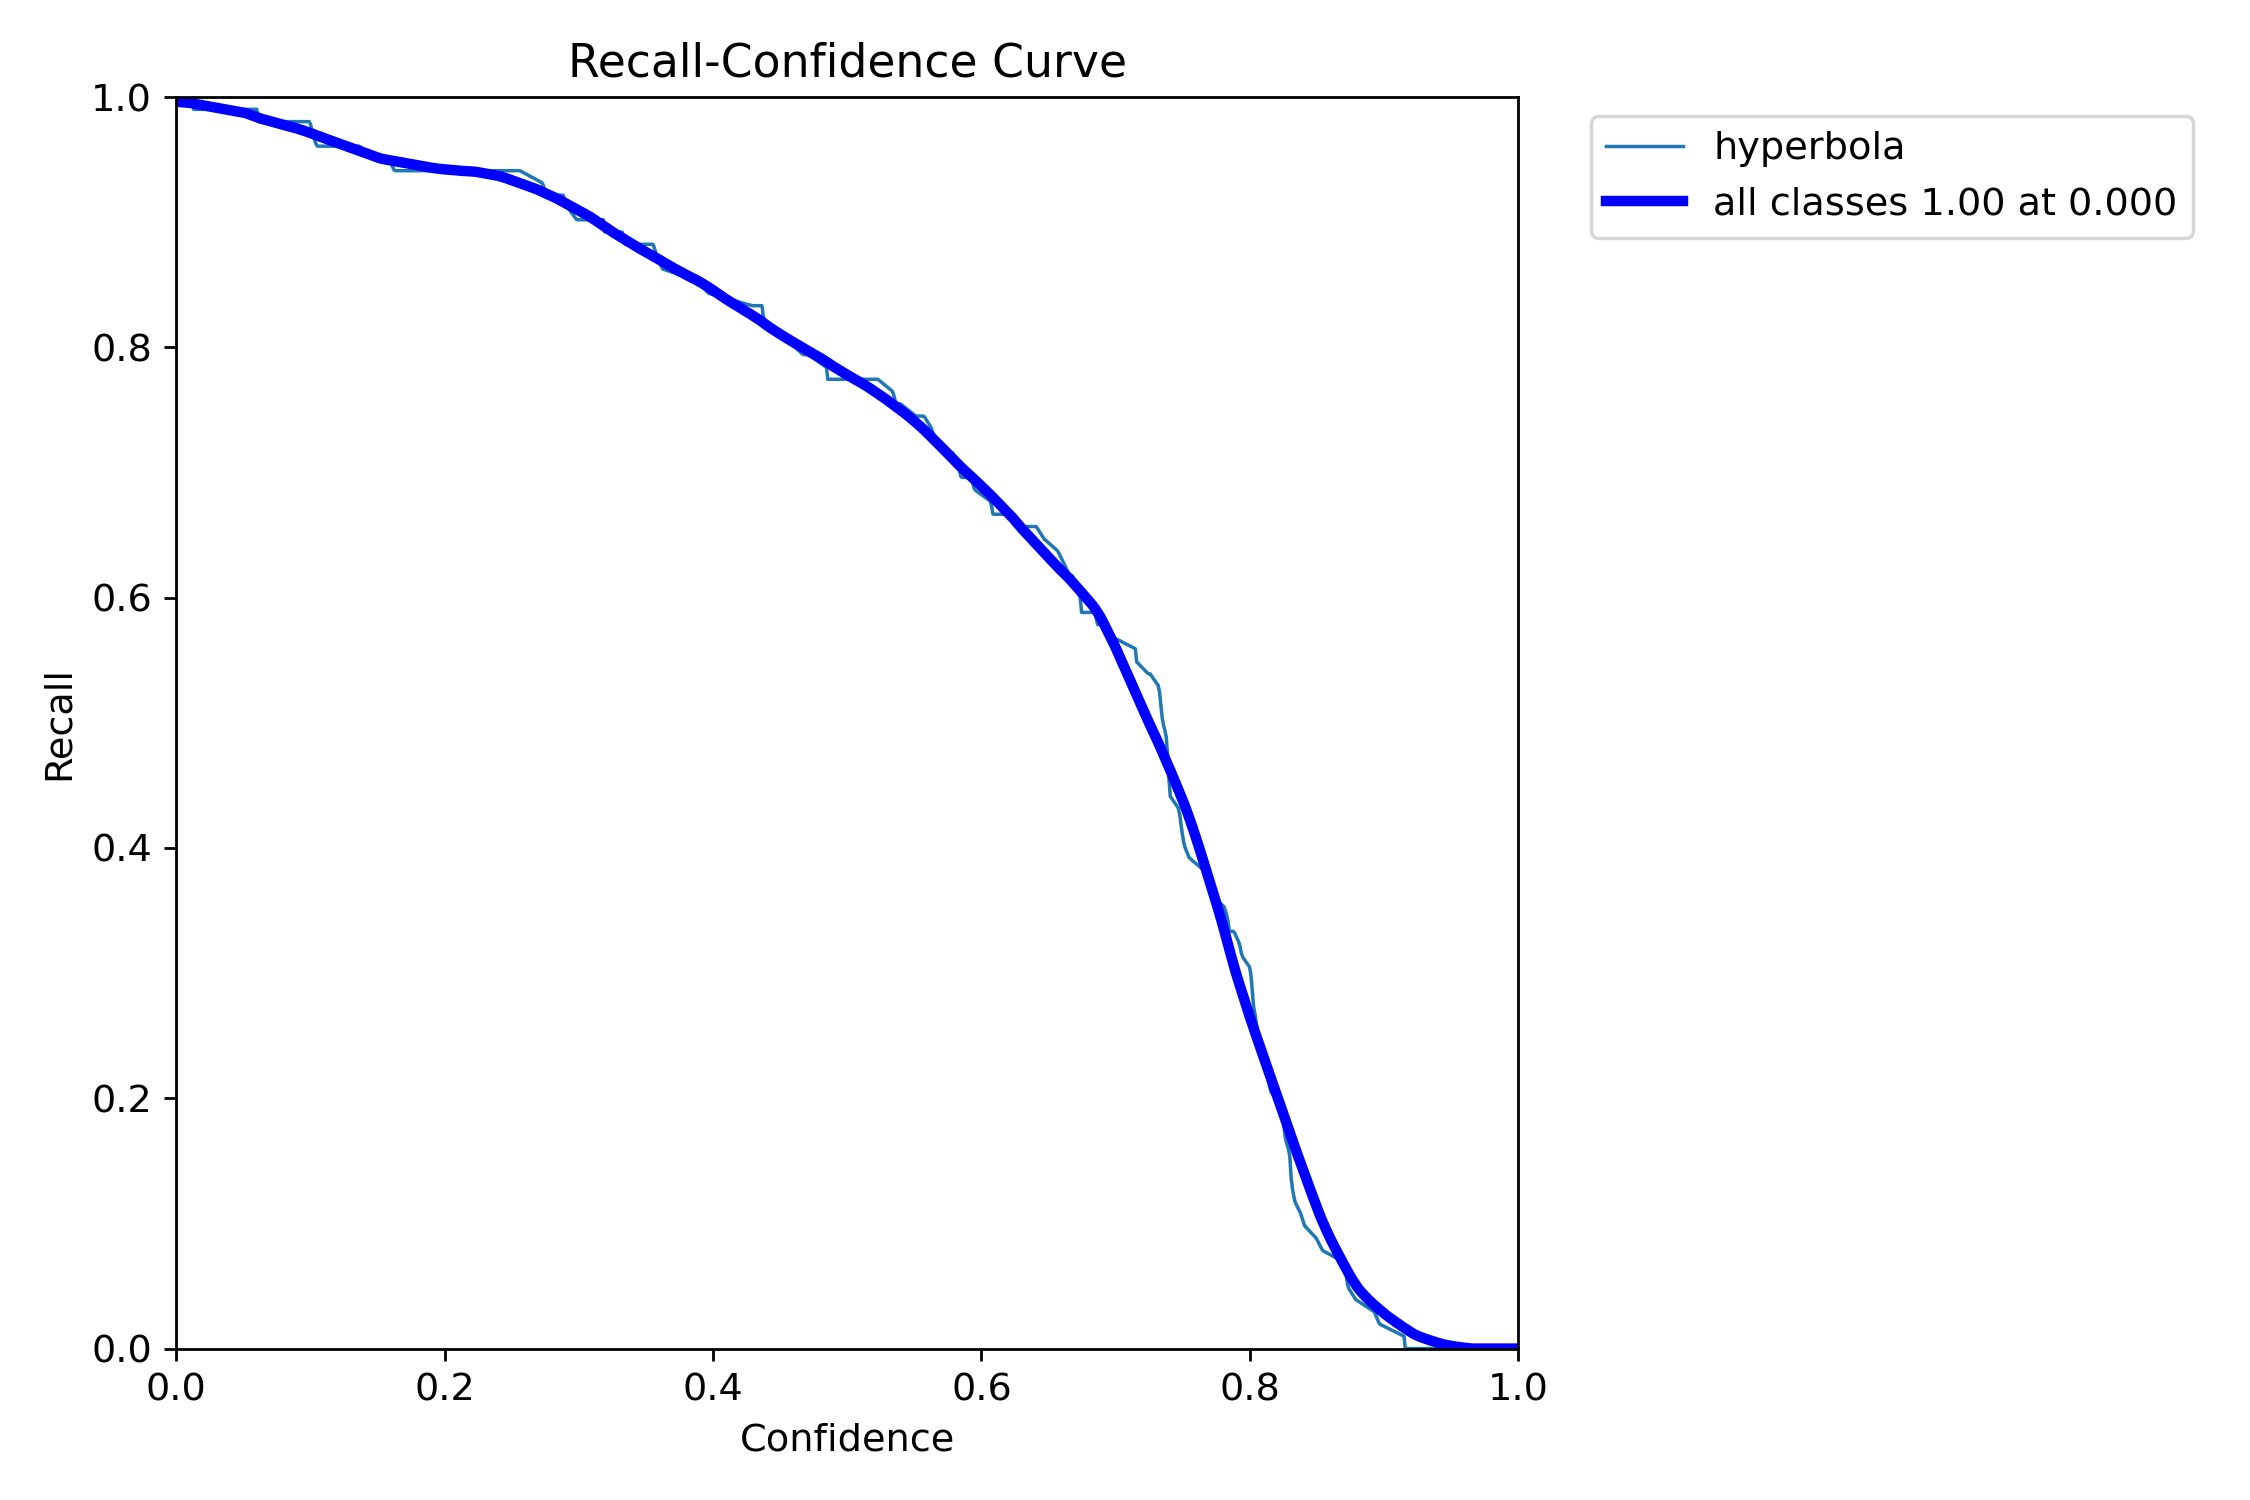

shows that with higher threshold for confidence the recall is decreasing which means that with a higher confidence fewer Objects are actually a Hyperbola which makes sence then not all objects that are detectet the confidence is 1

Precision Recall curve

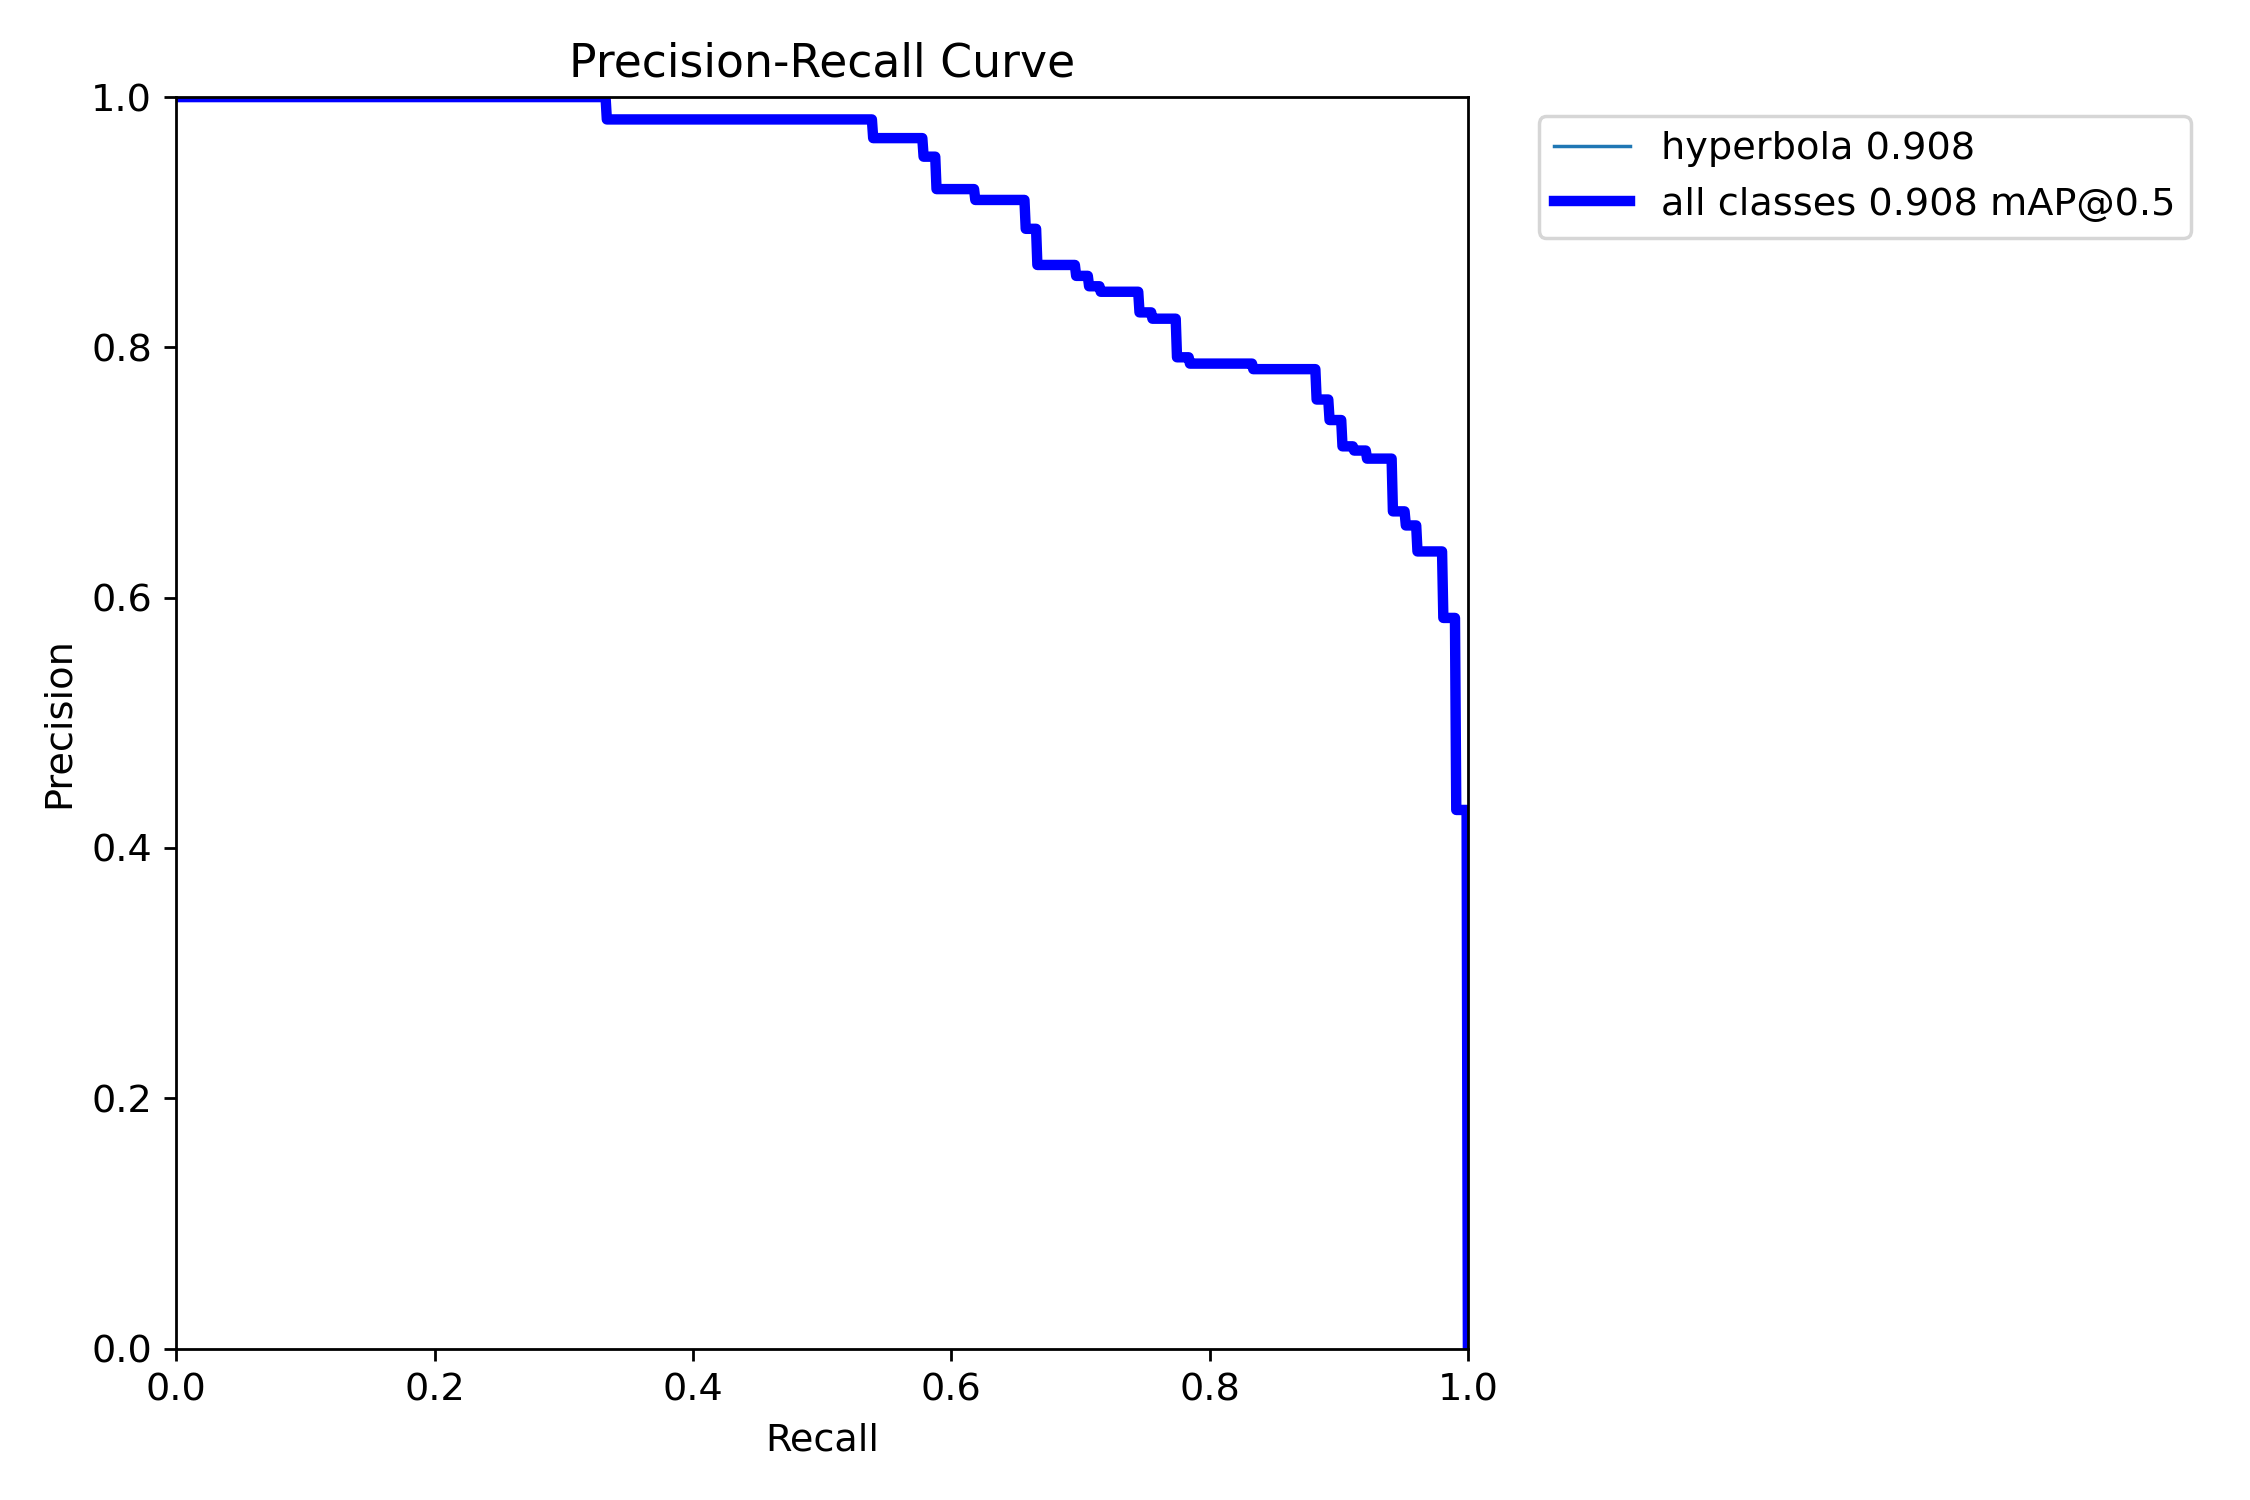

Is the basis ofe the mAP 50 which is the are und the Curve. That means if the Area under the curve is bigger that there is higher precision and recall. so for this plot it is shown thaht the curve is in the upper right which means there is a balance between precision and recall

F1 Score

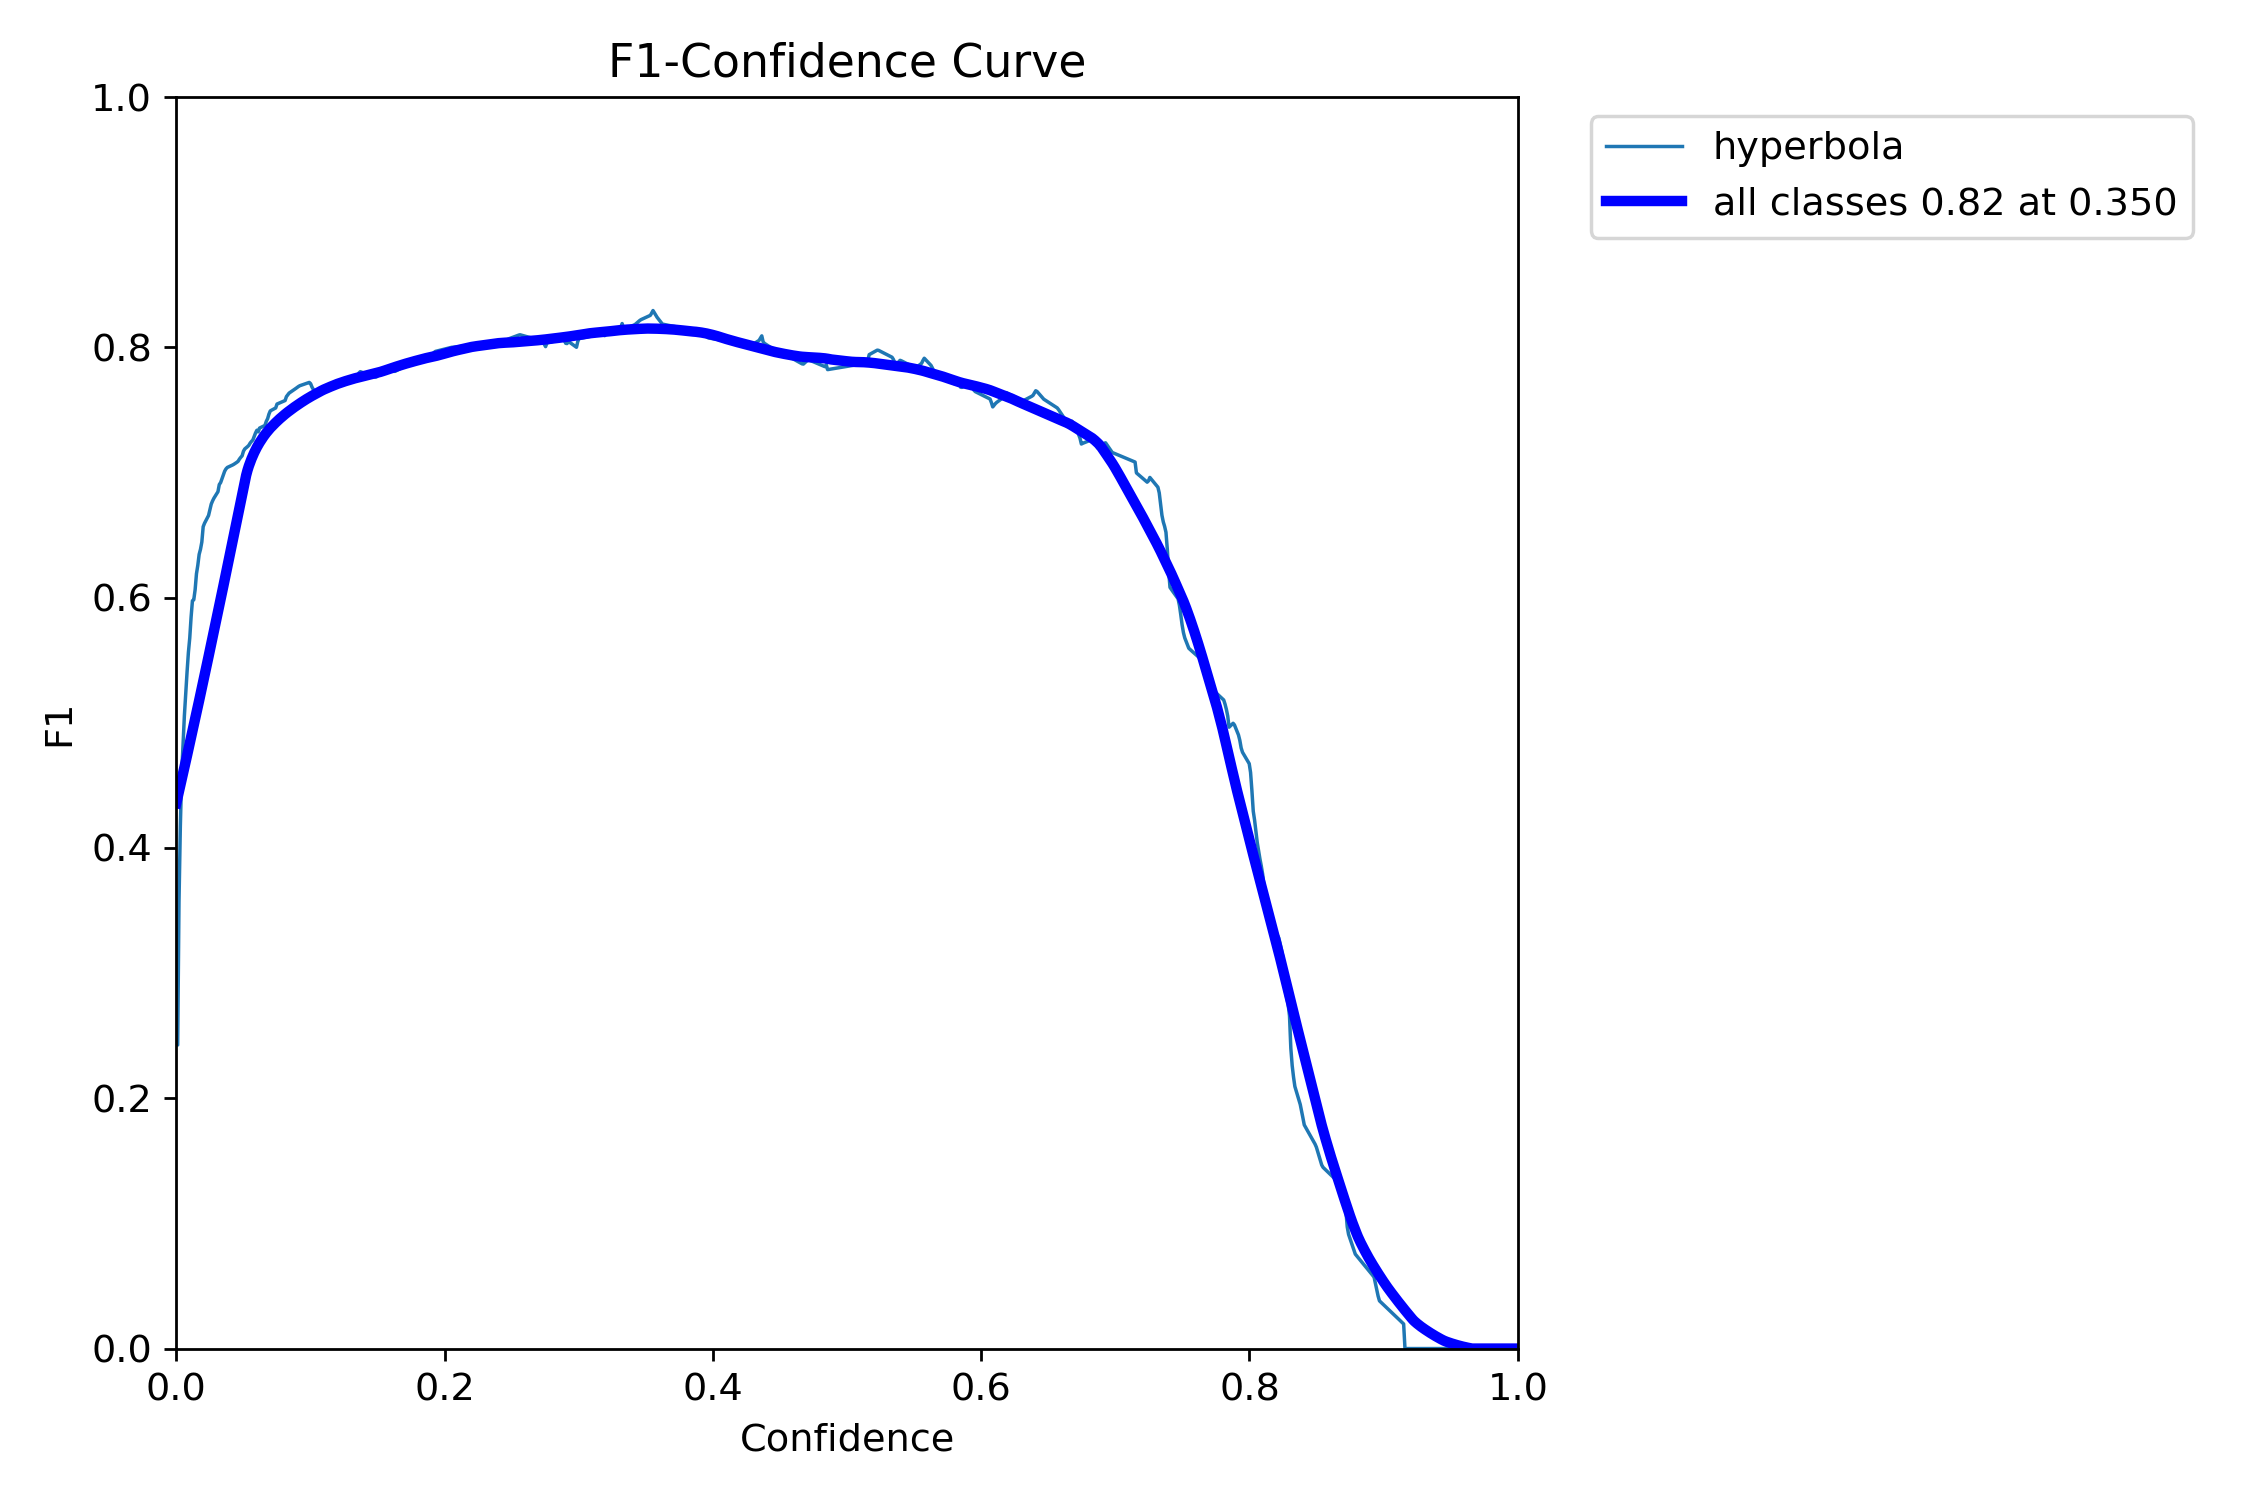

this is the harmonization betweend precision and recall with this plot it can be found that there are the best results if predictions are made at confidence 0.350

Confusion Matrix

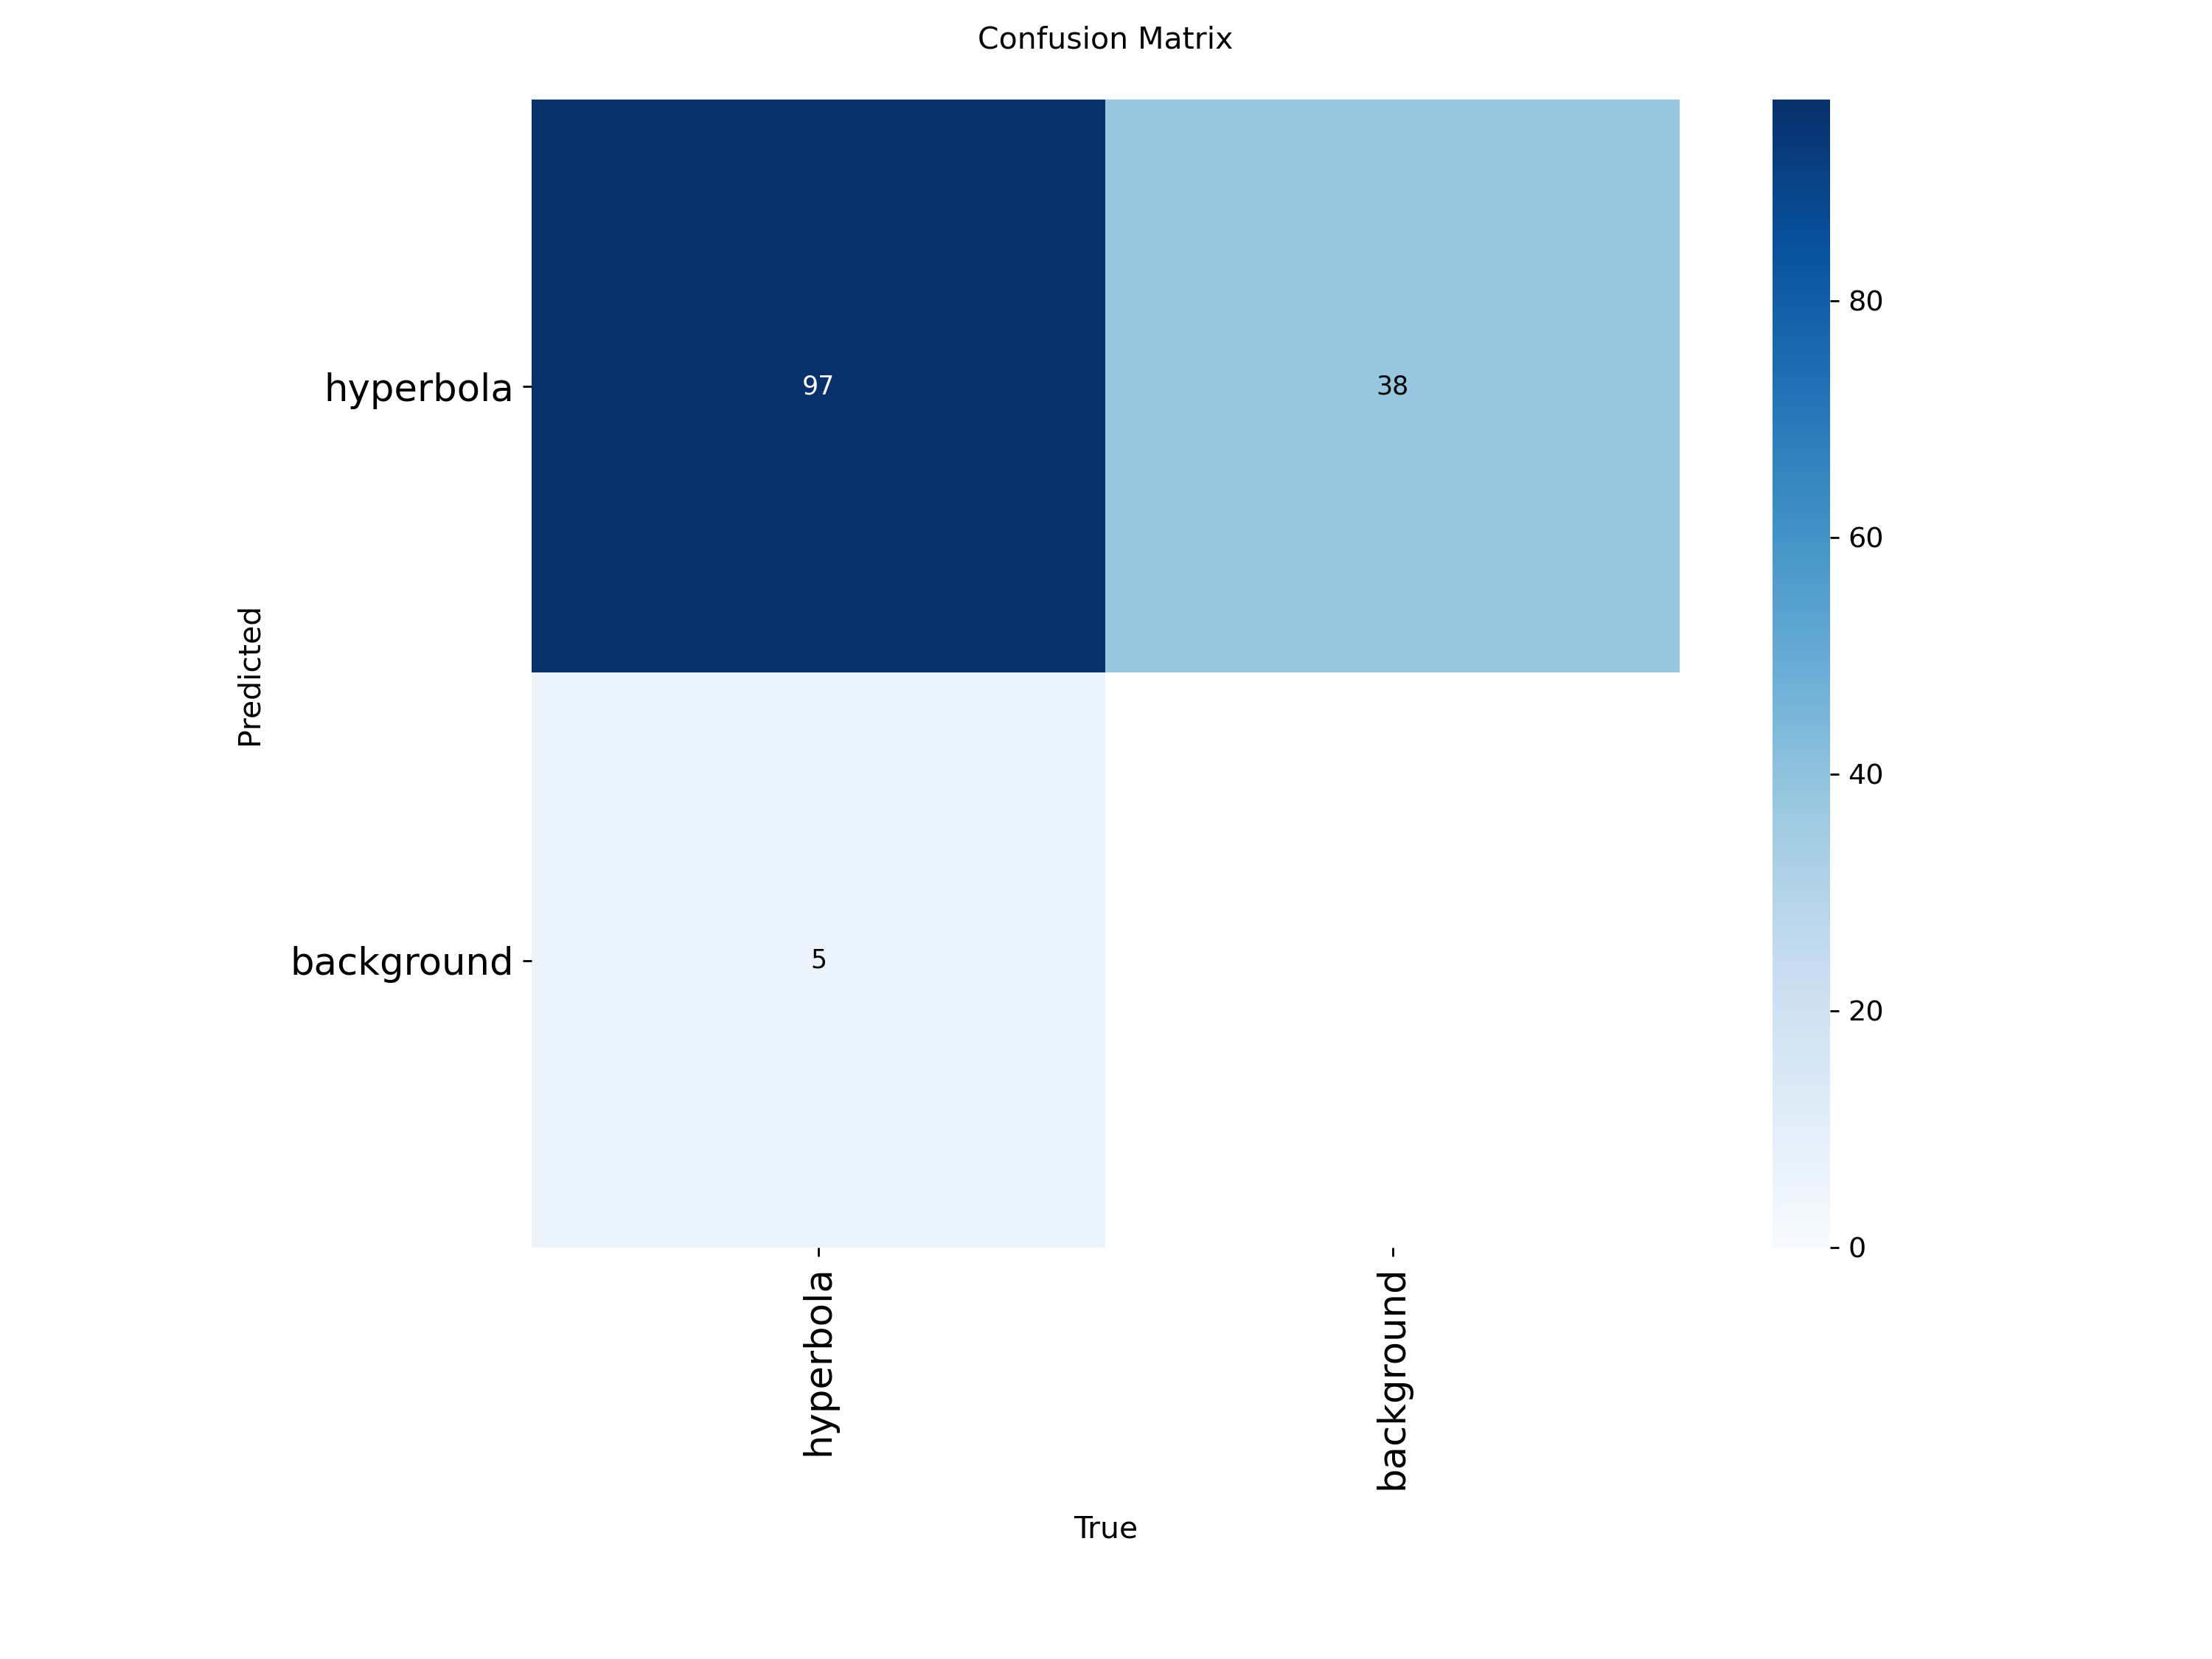

The Plot shows that there are only 5 False Negatives which influences the Recall negatively. And there are 38 False Positives which influences the Precision negatively

##### Segmentation Modell Hyperbolas

Again doing first an intepretation of the Metrics for learning but here metrics for Segmentation are added to the plot.

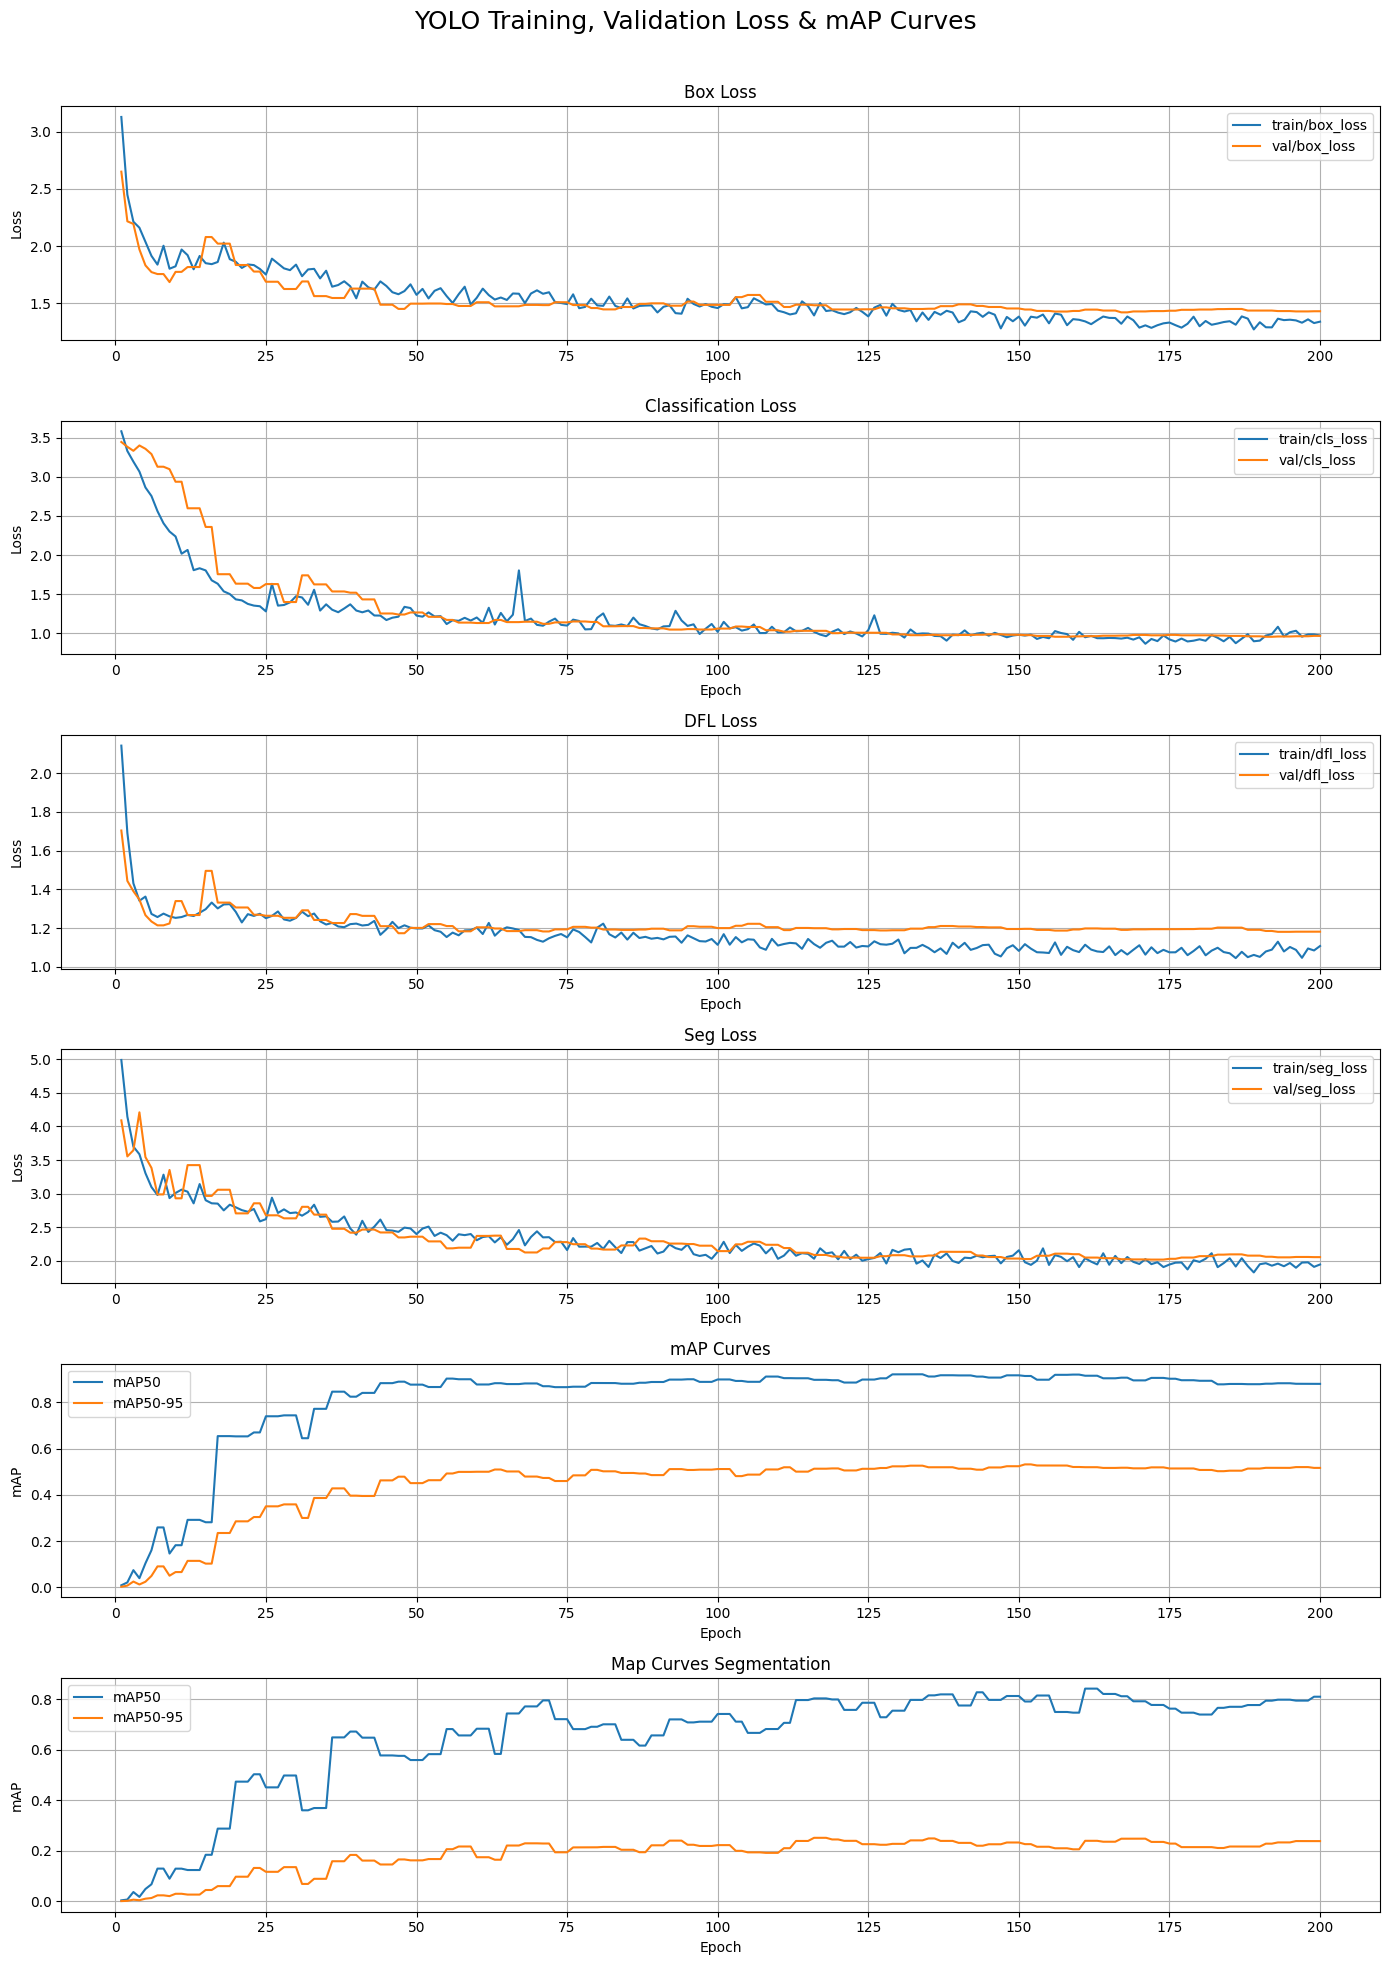

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV laden
df = pd.read_csv(BASE_DIR / "YOLO_Model_seg/Hyperbola_seg/results.csv")

# Plot-Größe
fig, axs = plt.subplots(6, 1, figsize=(14, 20))
fig.suptitle("YOLO Training, Validation Loss & mAP Curves", fontsize=18)

#box loss
axs[0].plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
axs[0].plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
axs[0].set_title("Box Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid()

#classification loss
axs[1].plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss")
axs[1].plot(df["epoch"], df["val/cls_loss"], label="val/cls_loss")
axs[1].set_title("Classification Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].legend()
axs[1].grid()

#dfl loss
axs[2].plot(df["epoch"], df["train/dfl_loss"], label="train/dfl_loss")
axs[2].plot(df["epoch"], df["val/dfl_loss"], label="val/dfl_loss")
axs[2].set_title("DFL Loss")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("Loss")
axs[2].legend()
axs[2].grid()

#seg_loss
axs[3].plot(df["epoch"], df["train/seg_loss"], label="train/seg_loss")
axs[3].plot(df["epoch"], df["val/seg_loss"], label="val/seg_loss")
axs[3].set_title("Seg Loss")
axs[3].set_xlabel("Epoch")
axs[3].set_ylabel("Loss")
axs[3].legend()
axs[3].grid()


#map boxes
axs[4].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axs[4].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axs[4].set_title("mAP Curves")
axs[4].set_xlabel("Epoch")
axs[4].set_ylabel("mAP")
axs[4].legend()
axs[4].grid()

#map masks
axs[5].plot(df["epoch"], df["metrics/mAP50(M)"], label="mAP50")
axs[5].plot(df["epoch"], df["metrics/mAP50-95(M)"], label="mAP50-95")
axs[5].set_title("Map Curves Segmentation")
axs[5].set_xlabel("Epoch")
axs[5].set_ylabel("mAP")
axs[5].legend()
axs[5].grid()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


**Intepretation**

**box_loss**
- **train**: over the epochs the loss decreases which means the model is learning which means the model is learning to accuratly predict the boxes.
- **val**: follows similar to the train curve which means it generalizes good to the data no tendency for overfitting shown.

**class_loss**
- **train**: here it is shown that over the 200 Epochs the train_loss is decreasing steadly which means the model learns how to correctly classify the objects.
- **val**: there is the same tendency seen for the validation set. So the updatet weight are working with respect to the class_loss for generalization.
But when put in to perspective its actually expectet since there is only one 

**dfl_loss**
- **train**: her again over the 200 epoch always decreeasing which means the model learns how to make more accurate predictions for the Distribution of the coordinates of the boxes.
- **val**: pretty similar to the train curve but seems like after 100 epochs not really decreasing anymore which means generalizations as whole is pretty good but maybe there is a argument for fewer epochs.

**seg_loss**
- **train**: shows over the 200 epochs a always decrasing curve which means that the model learns to predict the segmentation masks (polygons) more accuratly.
- **val**: follows a similar path as the train curve which means generalization is good and no tendency for overfitting

**mAP (Boxes)**
- **mAP50**: inreases strongly and after around 60 epochs steady above 0.8 which indicates that the can detect Objects with respect to IOU 50.
-**mAP50-95** lower as the mAP50 but this is expected but the performance after around 60 Epochs around 0.5 which means the predictions are quite precise

**mAP(Masks)**
- **mAP50**: fluctuates more than mAP50 for boxes. At around epoch 125 pretty steady around 0.8 which means that th model matches the masks pretty god with respect to IOU 50.
- **mAP50-95**: lower than mAP50 as expectet because its a more strict measure so thaht means for higher IOU thresholds its not that precise but could be a indicator for more training images

Lets make a validation and look at the metrics.

In [15]:
#Validation Segmentation Hyperbolas

from ultralytics import YOLO

#load model
model_seg_h = YOLO(YOLO_MODEL_SEG_H_DIR)

#validate model
metrics_seg_h = model_seg_h.val(data = YOLO_MODEL_SEG_H_YAML)

Ultralytics 8.3.208  Python-3.11.13 torch-2.8.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access  (ping: 0.40.1 ms, read: 105.422.2 MB/s, size: 75.4 KB)
val: Scanning C:\pythonad\PAINDHS25\PAINDGPR\Annotated_Data\YOLO_Segmentation_Hyperbola\valid\labels.cache... 4 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 0.9it/s 1.1s
                   all          4         94      0.926      0.804      0.911      0.519      0.853      0.739      0.816      0.249
Speed: 3.0ms preprocess, 145.7ms inference, 0.0ms loss, 66.1ms postprocess per image
Results saved to C:\pythonad\PAINDHS25\PAINDGPR\Notebooks\runs\segment\val


For the metrics in this part only the metrics with respect to the mask are shown because fitting is done on those.

In [20]:
metrics_seg_h

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001869768C210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [24]:
# looking at map 50 and map 50.95
print(f"map50: {metrics_seg_h.seg.map50}")
print(f"map50-95: {metrics_seg_h.seg.map}")

map50: 0.8159178095871854
map50-95: 0.24926570497692624


**mAP50**
it shows that the mAP is 0.82 for the IOU of 50 that means mask get 81% correctly detected with IOU 50 \
**mAP50-95**
It shows that it lower because its stricter so its not as precise for higher thresholds for IOU that means maybe considering adding more images to the training dataset.

Precision

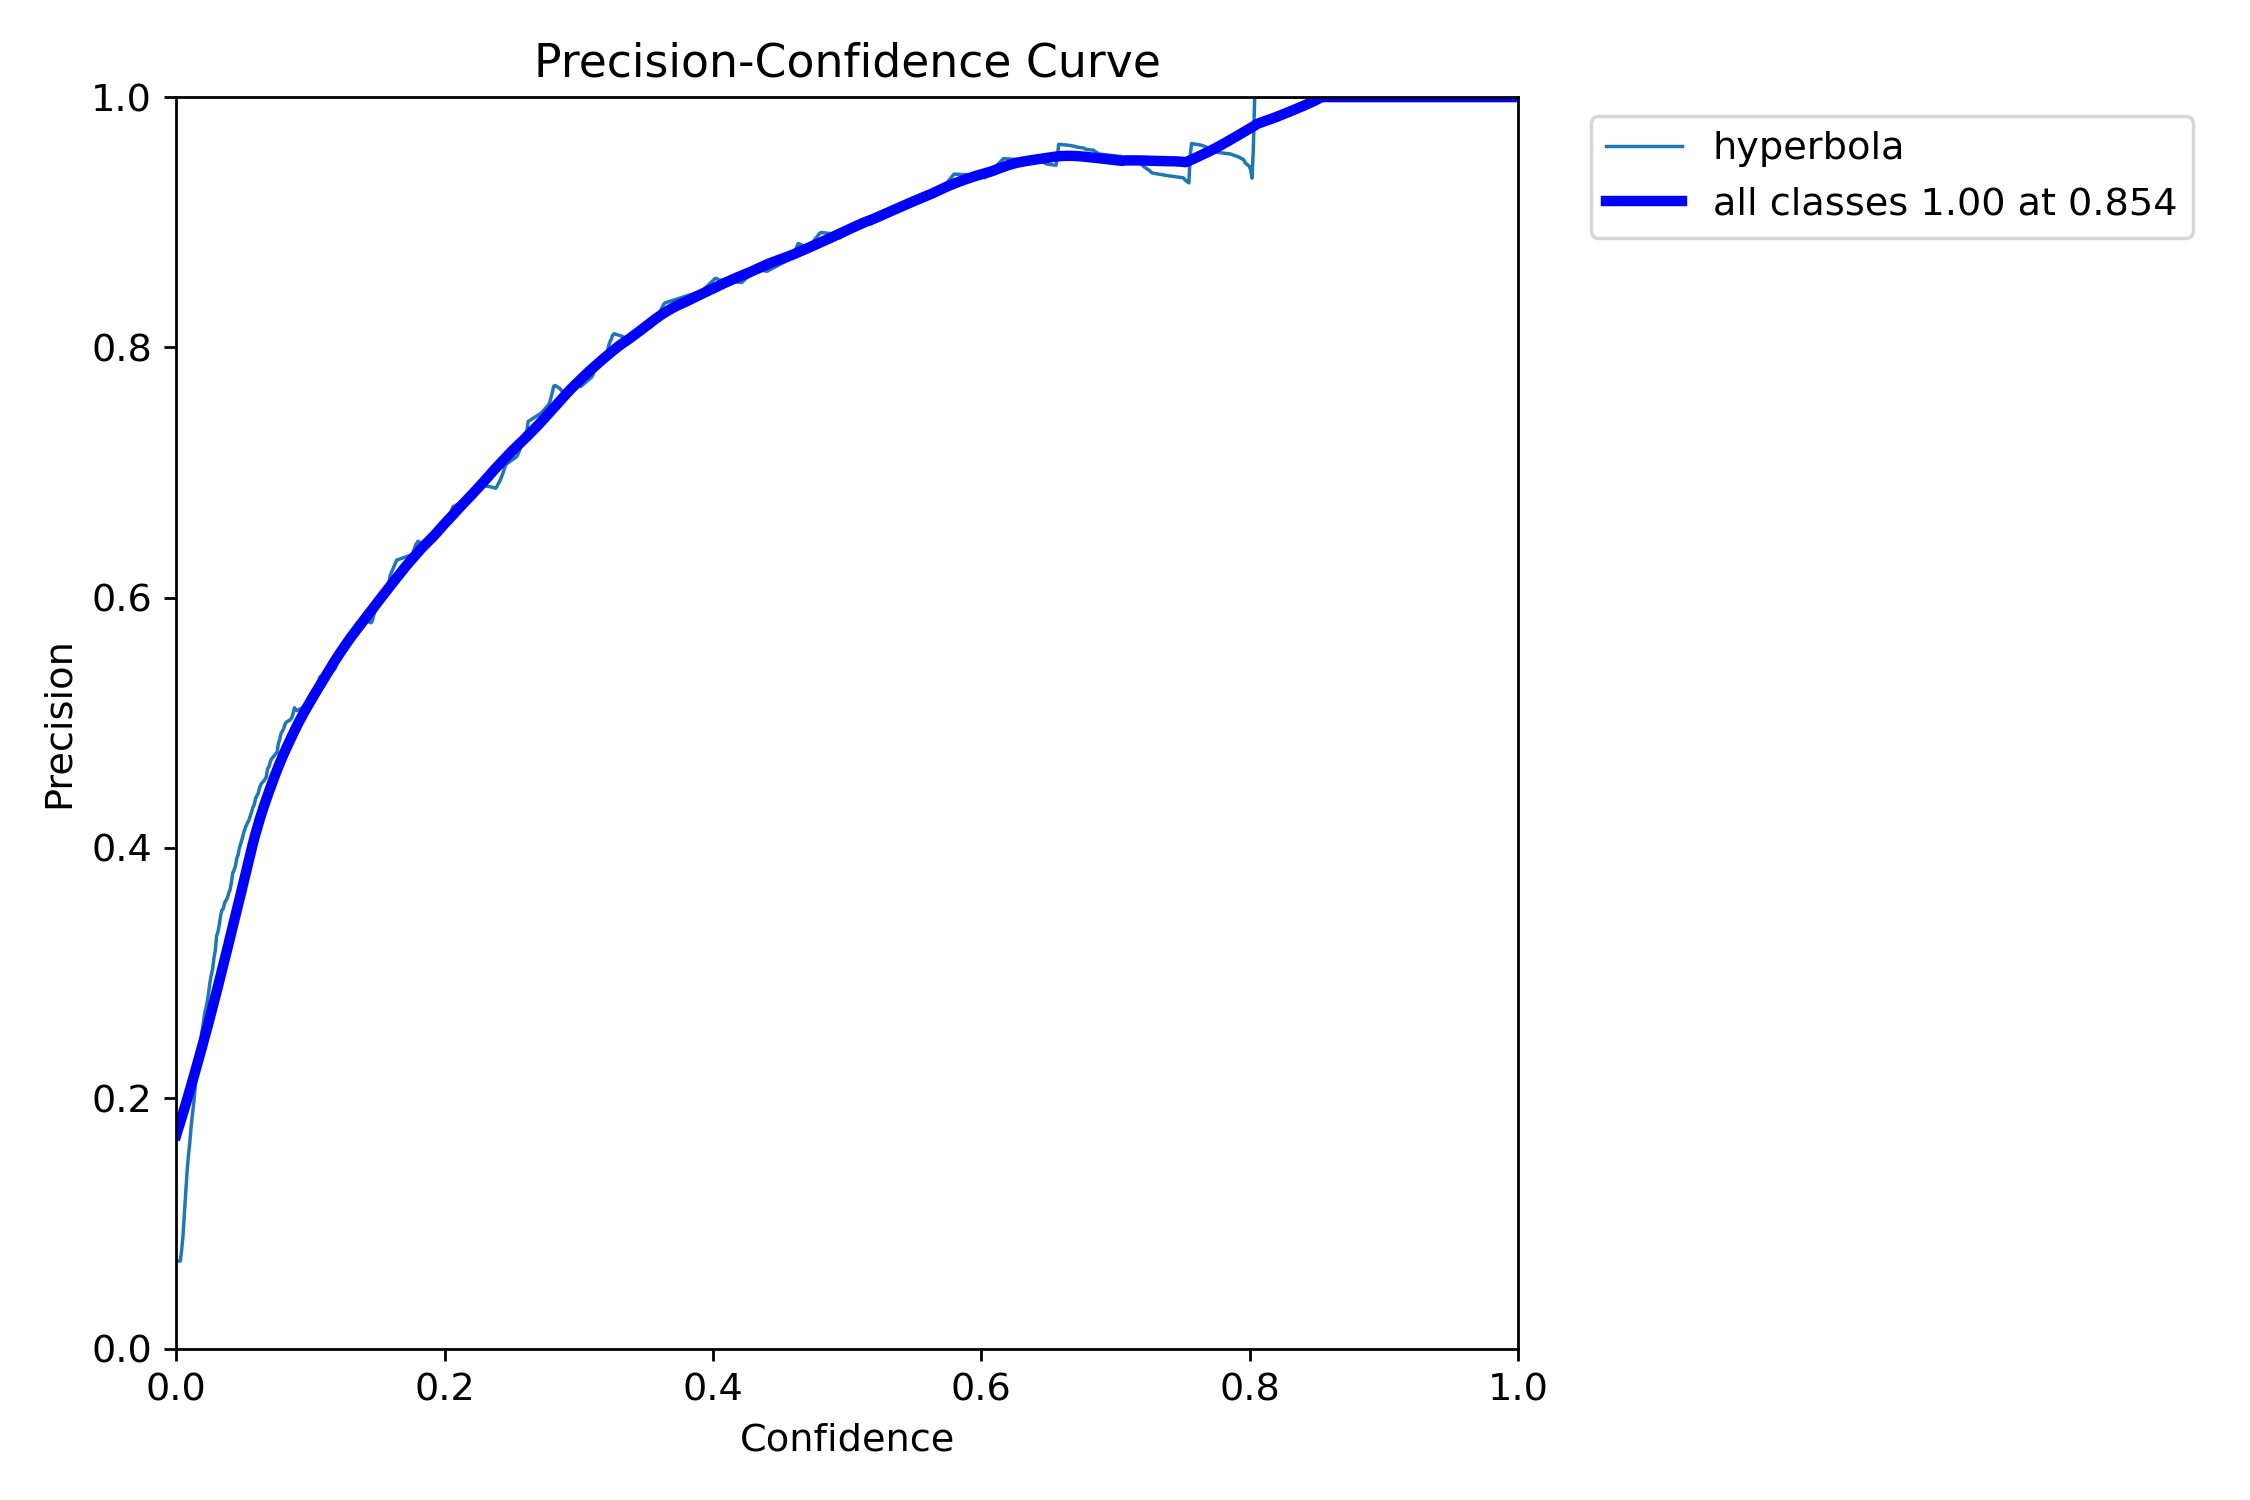

shows the correct relationship because if confidence is higher the precision should get higher. and with confidence 0.854 the model has 100% precision

Recall


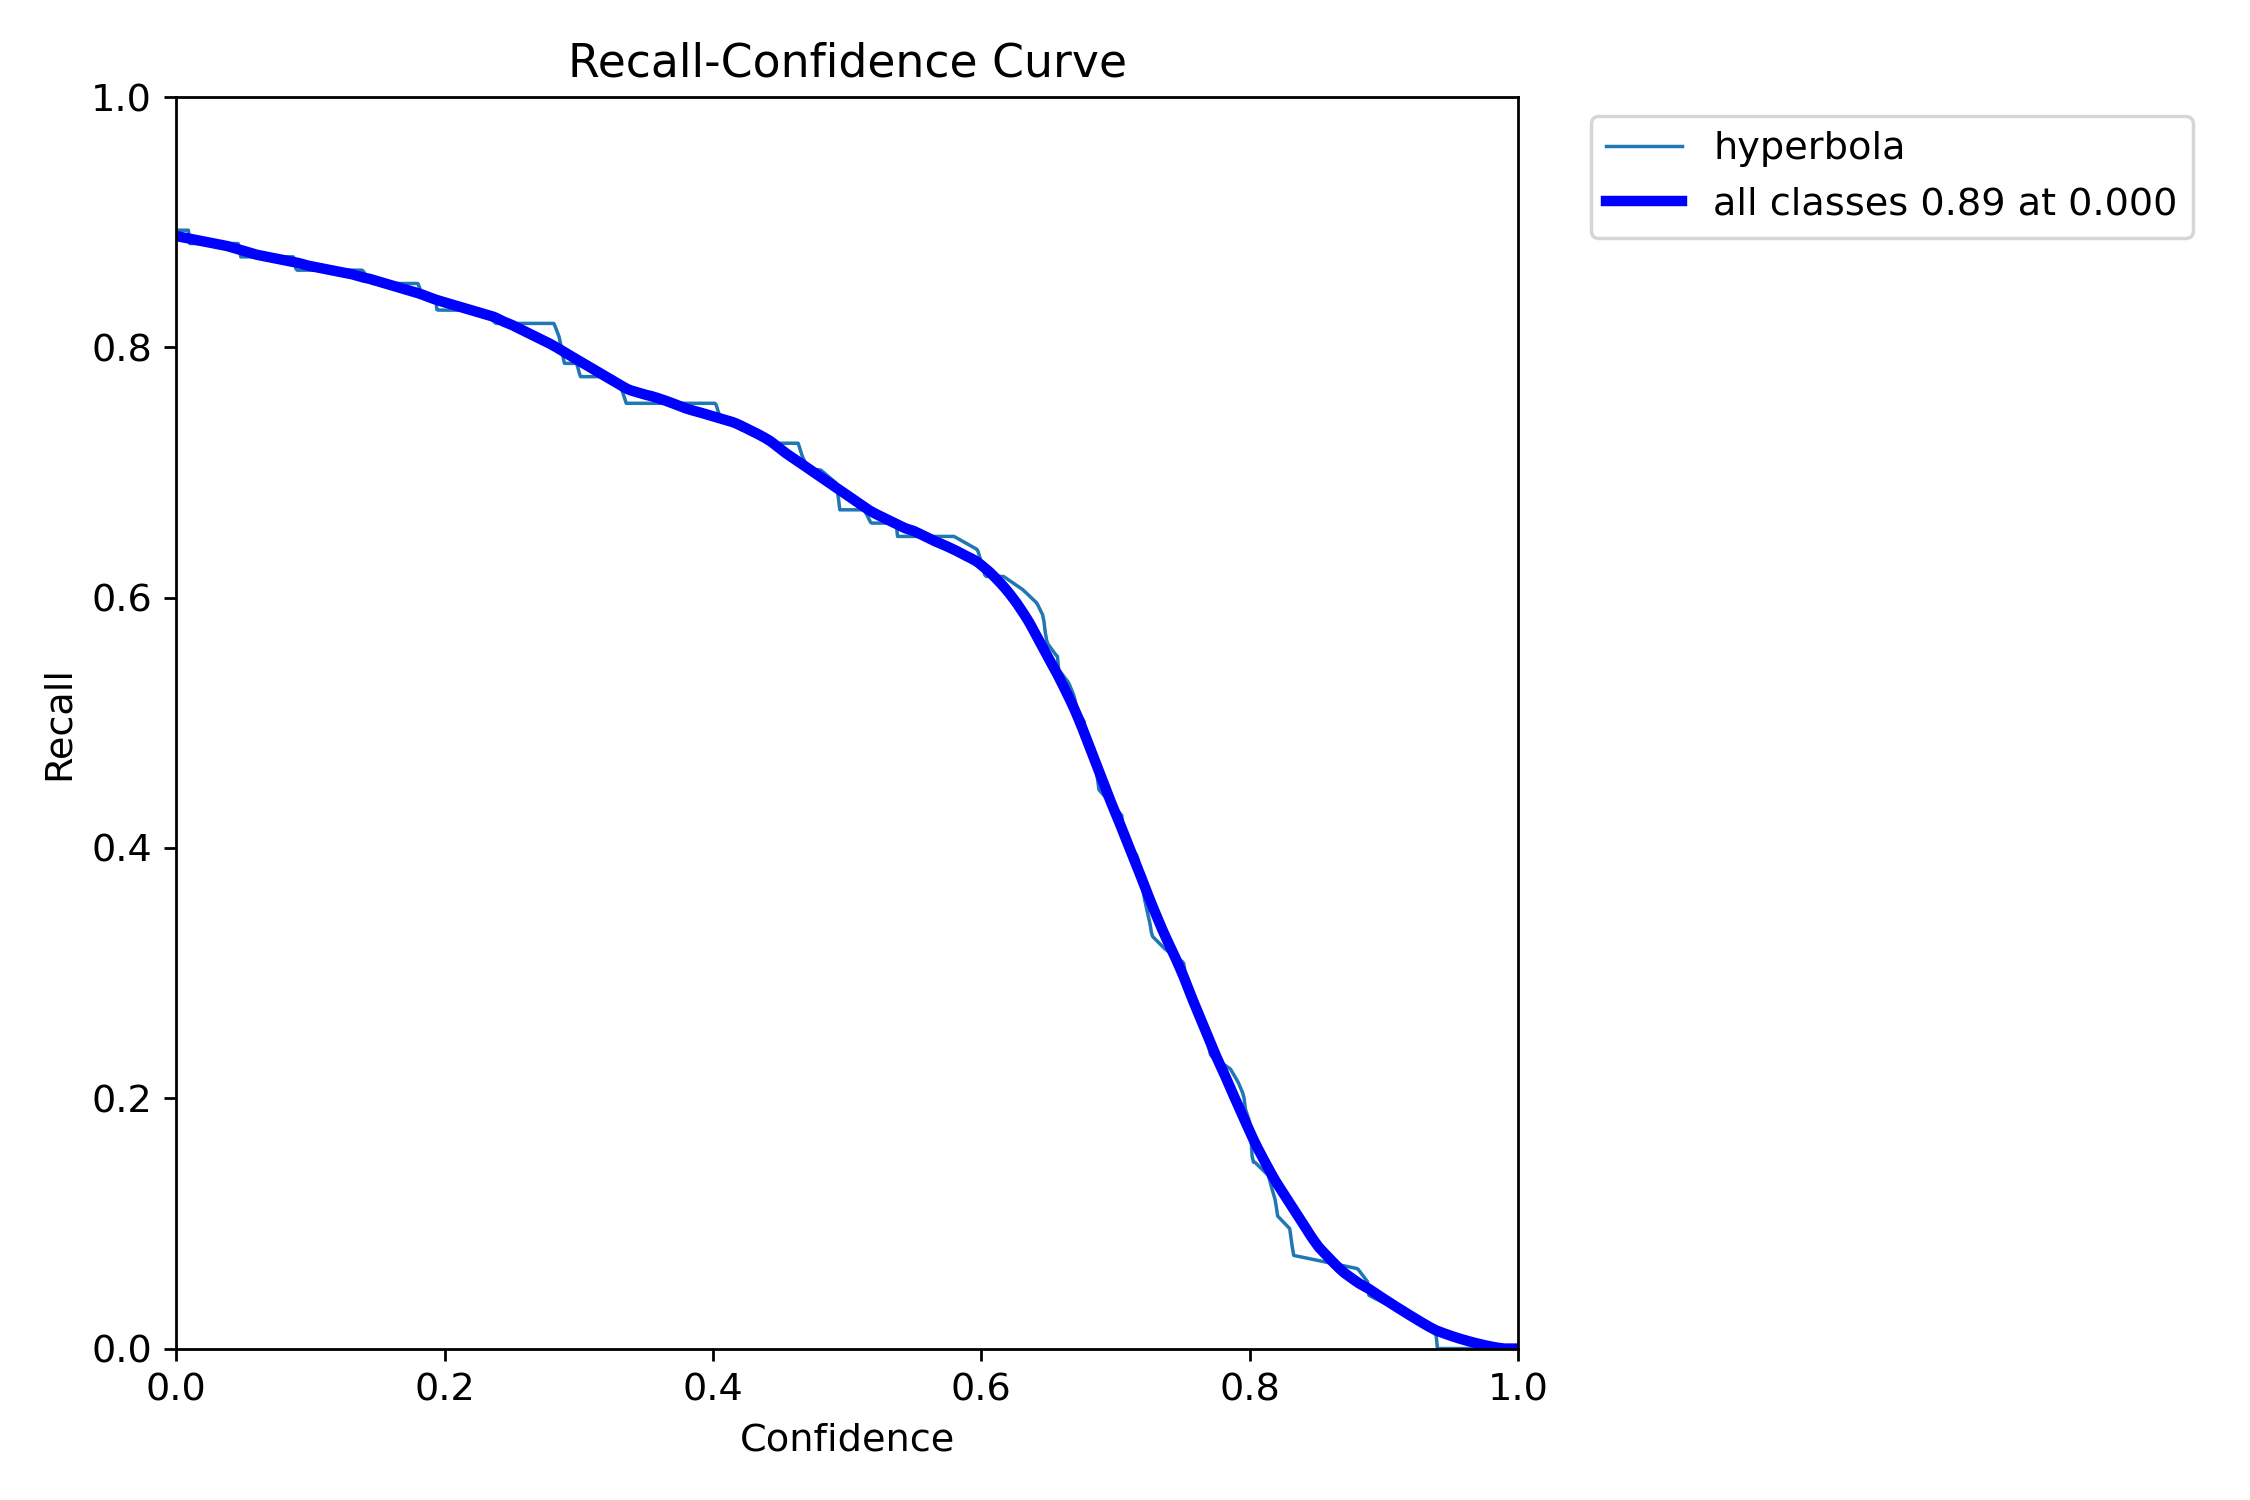

shows thath if increasing the confidence the lower the Detections which are really correctly detected whic is a expected relationship

Recall Precision Curve

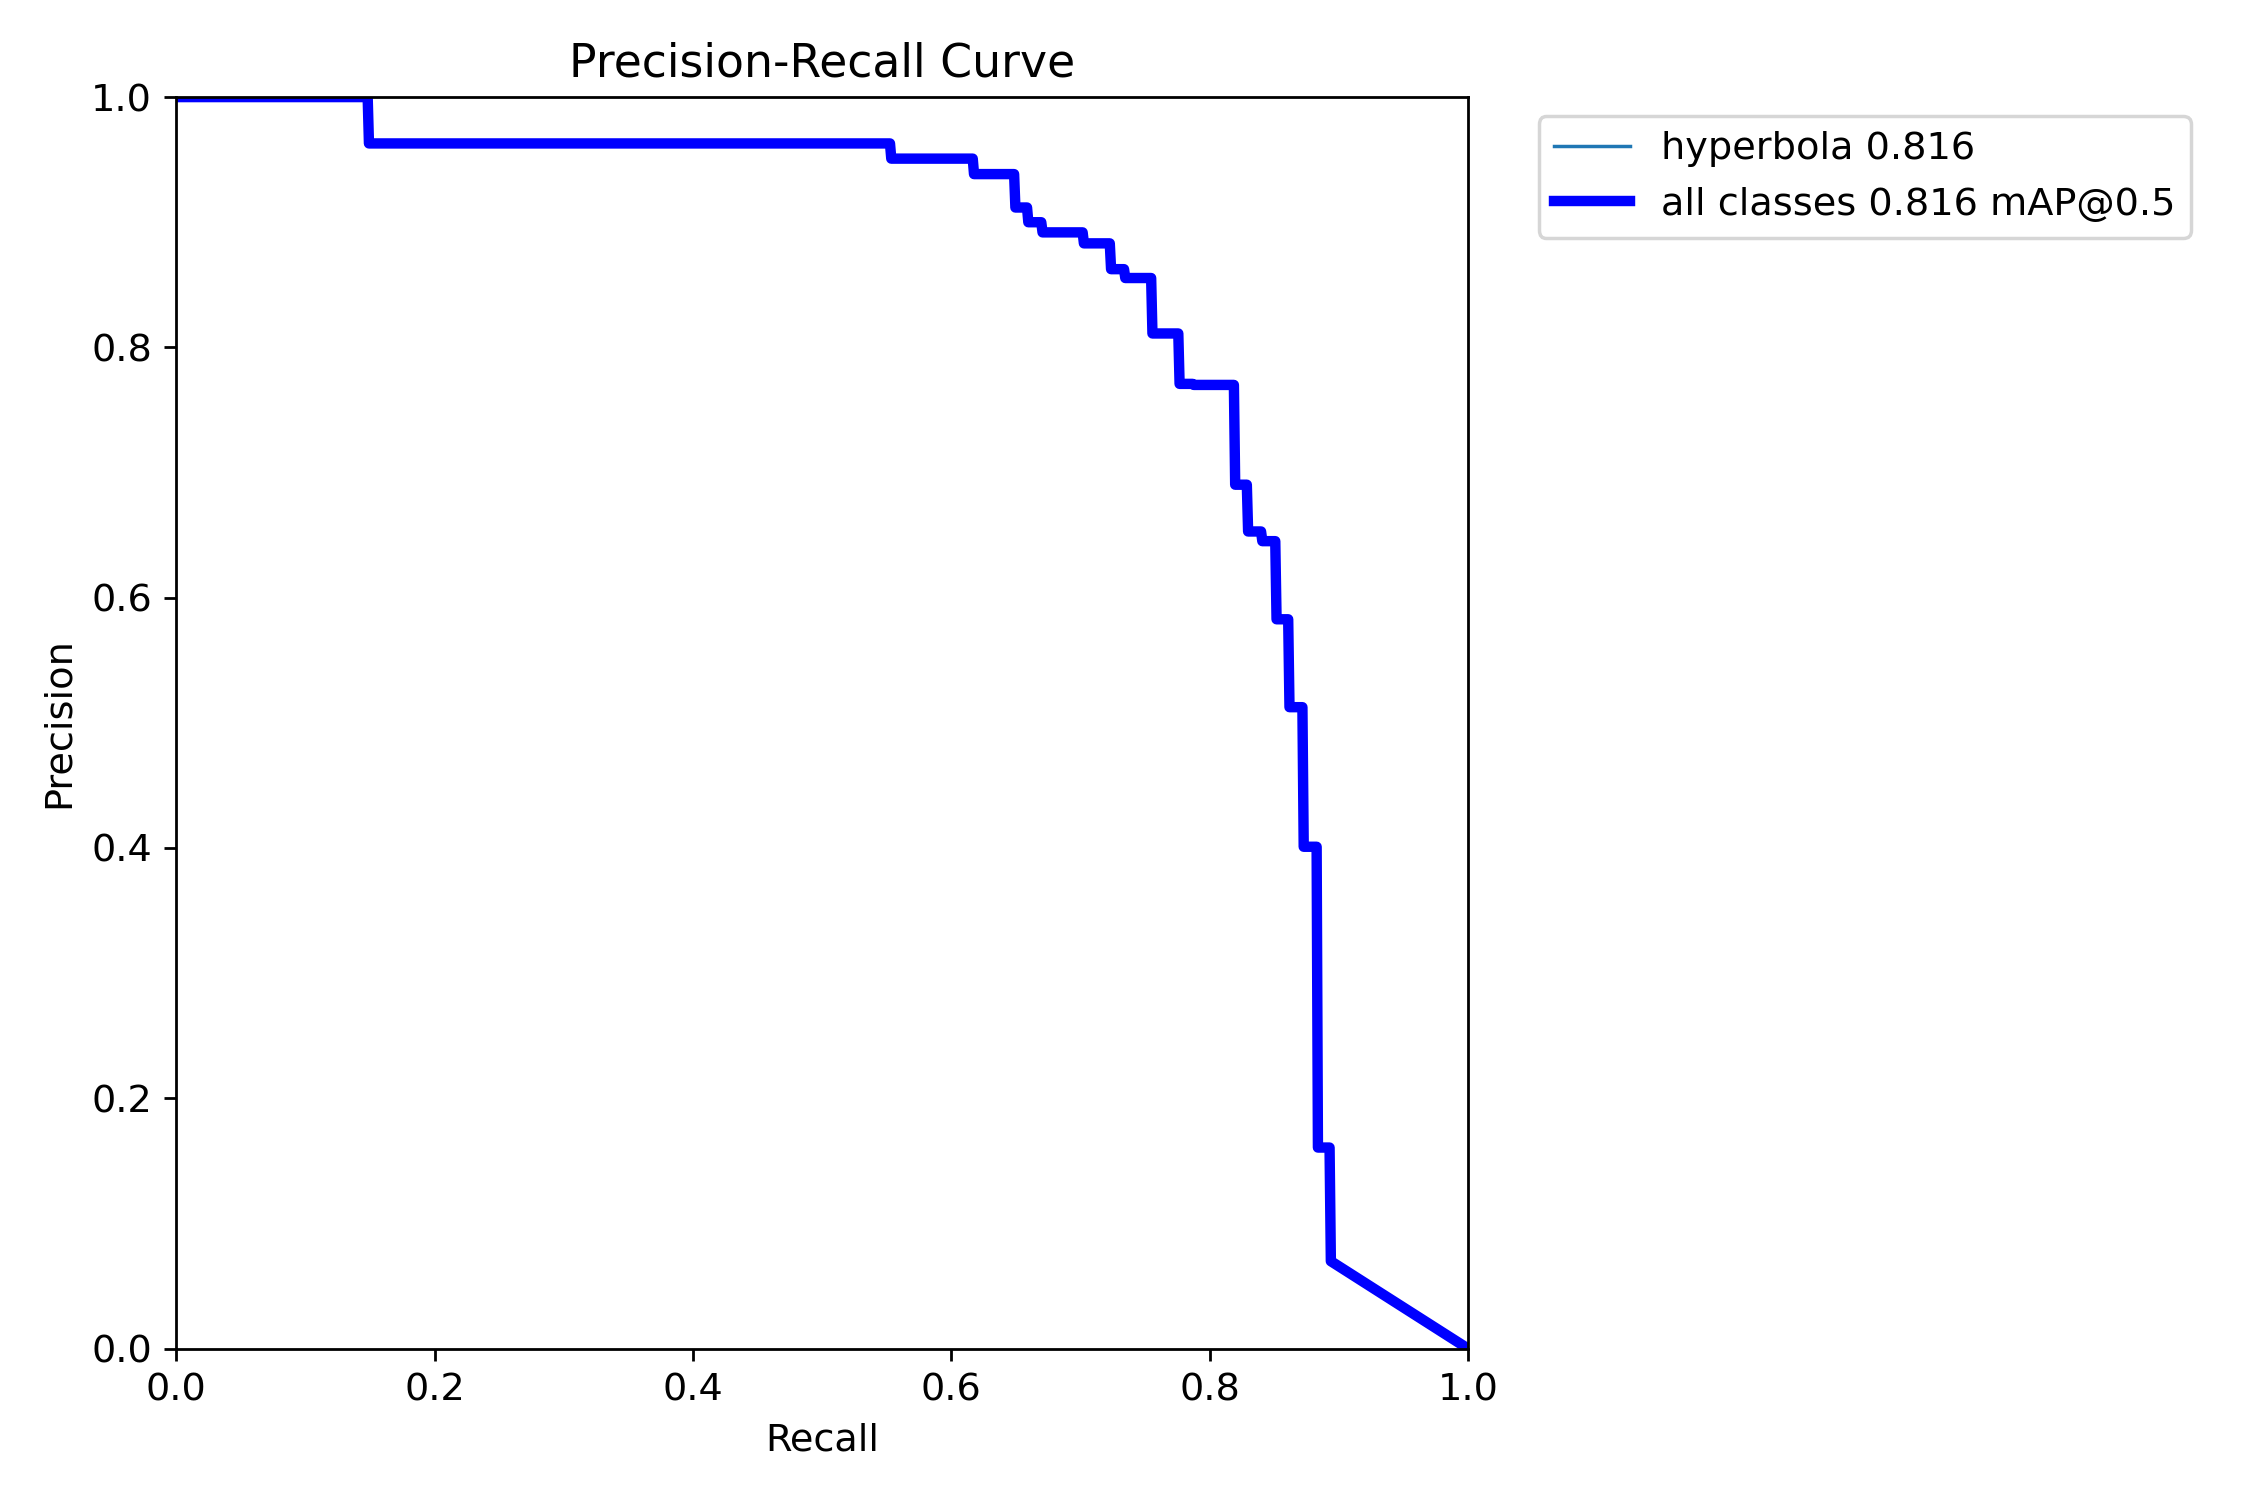

gives us the mAP50 for the masks. which is 0.816 that means this is the area under the curve. It shows that this area is pretty big and the cruve tends to the top right which is a good sign.

F1 Score

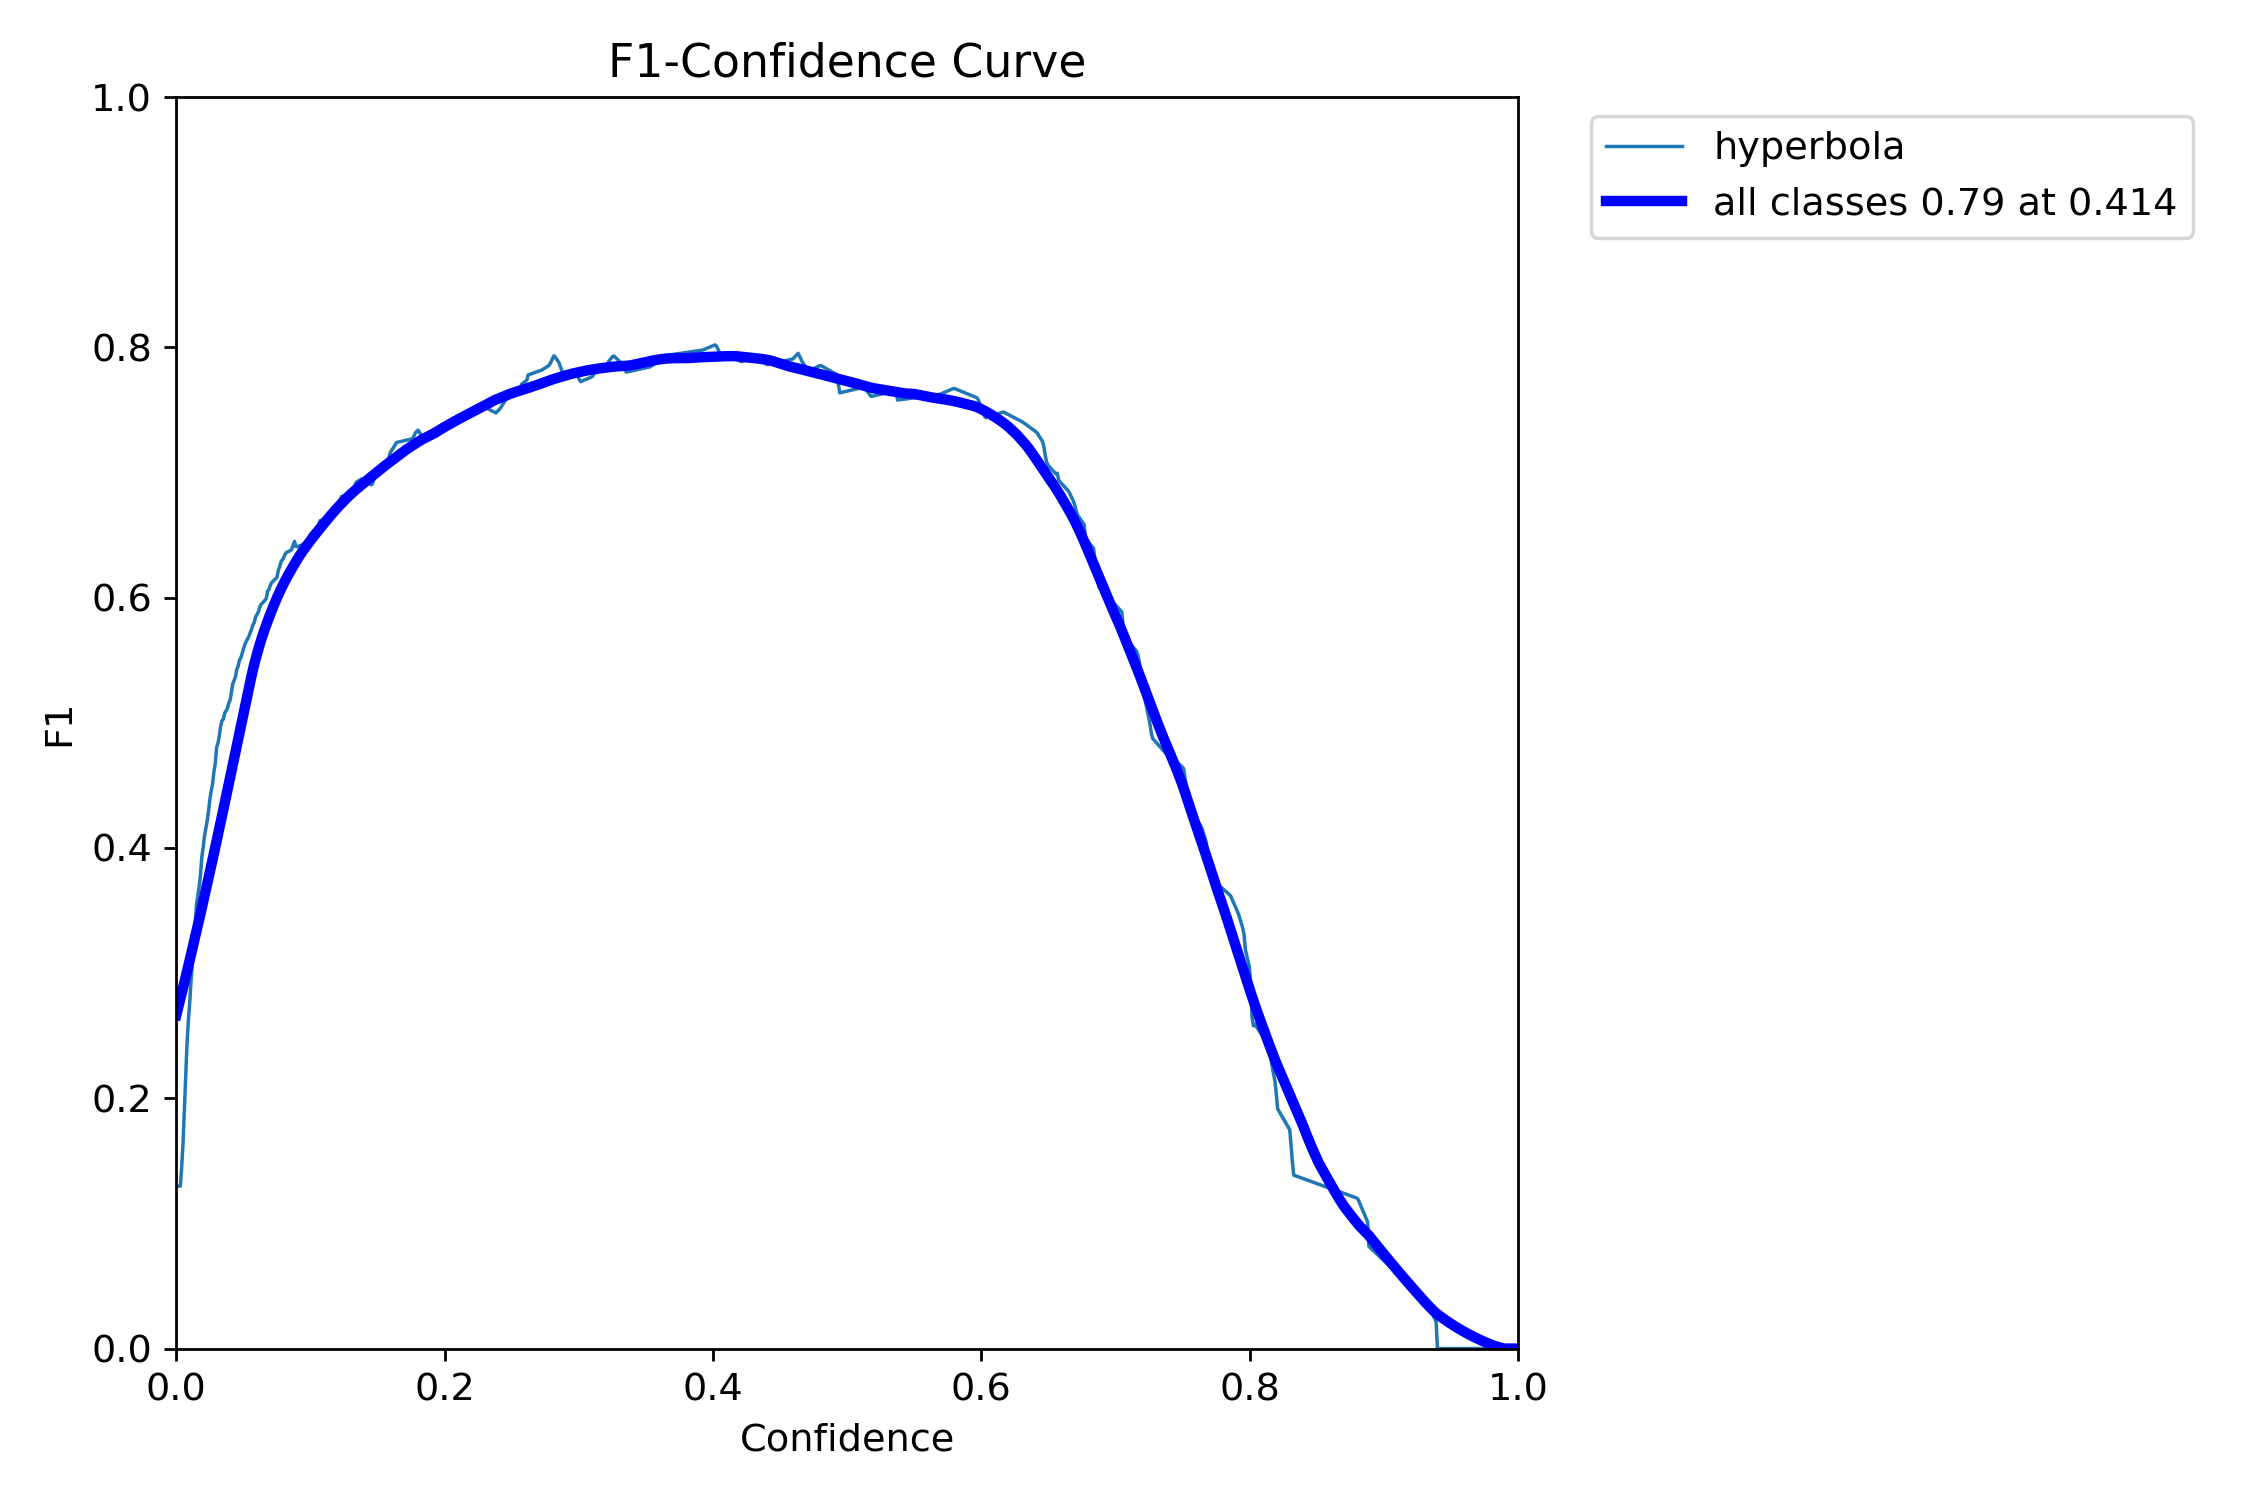

shows that for a confidence threshold of 0.414 most hyperbolas are correctly detected and are the most precise

Confusion Matrix

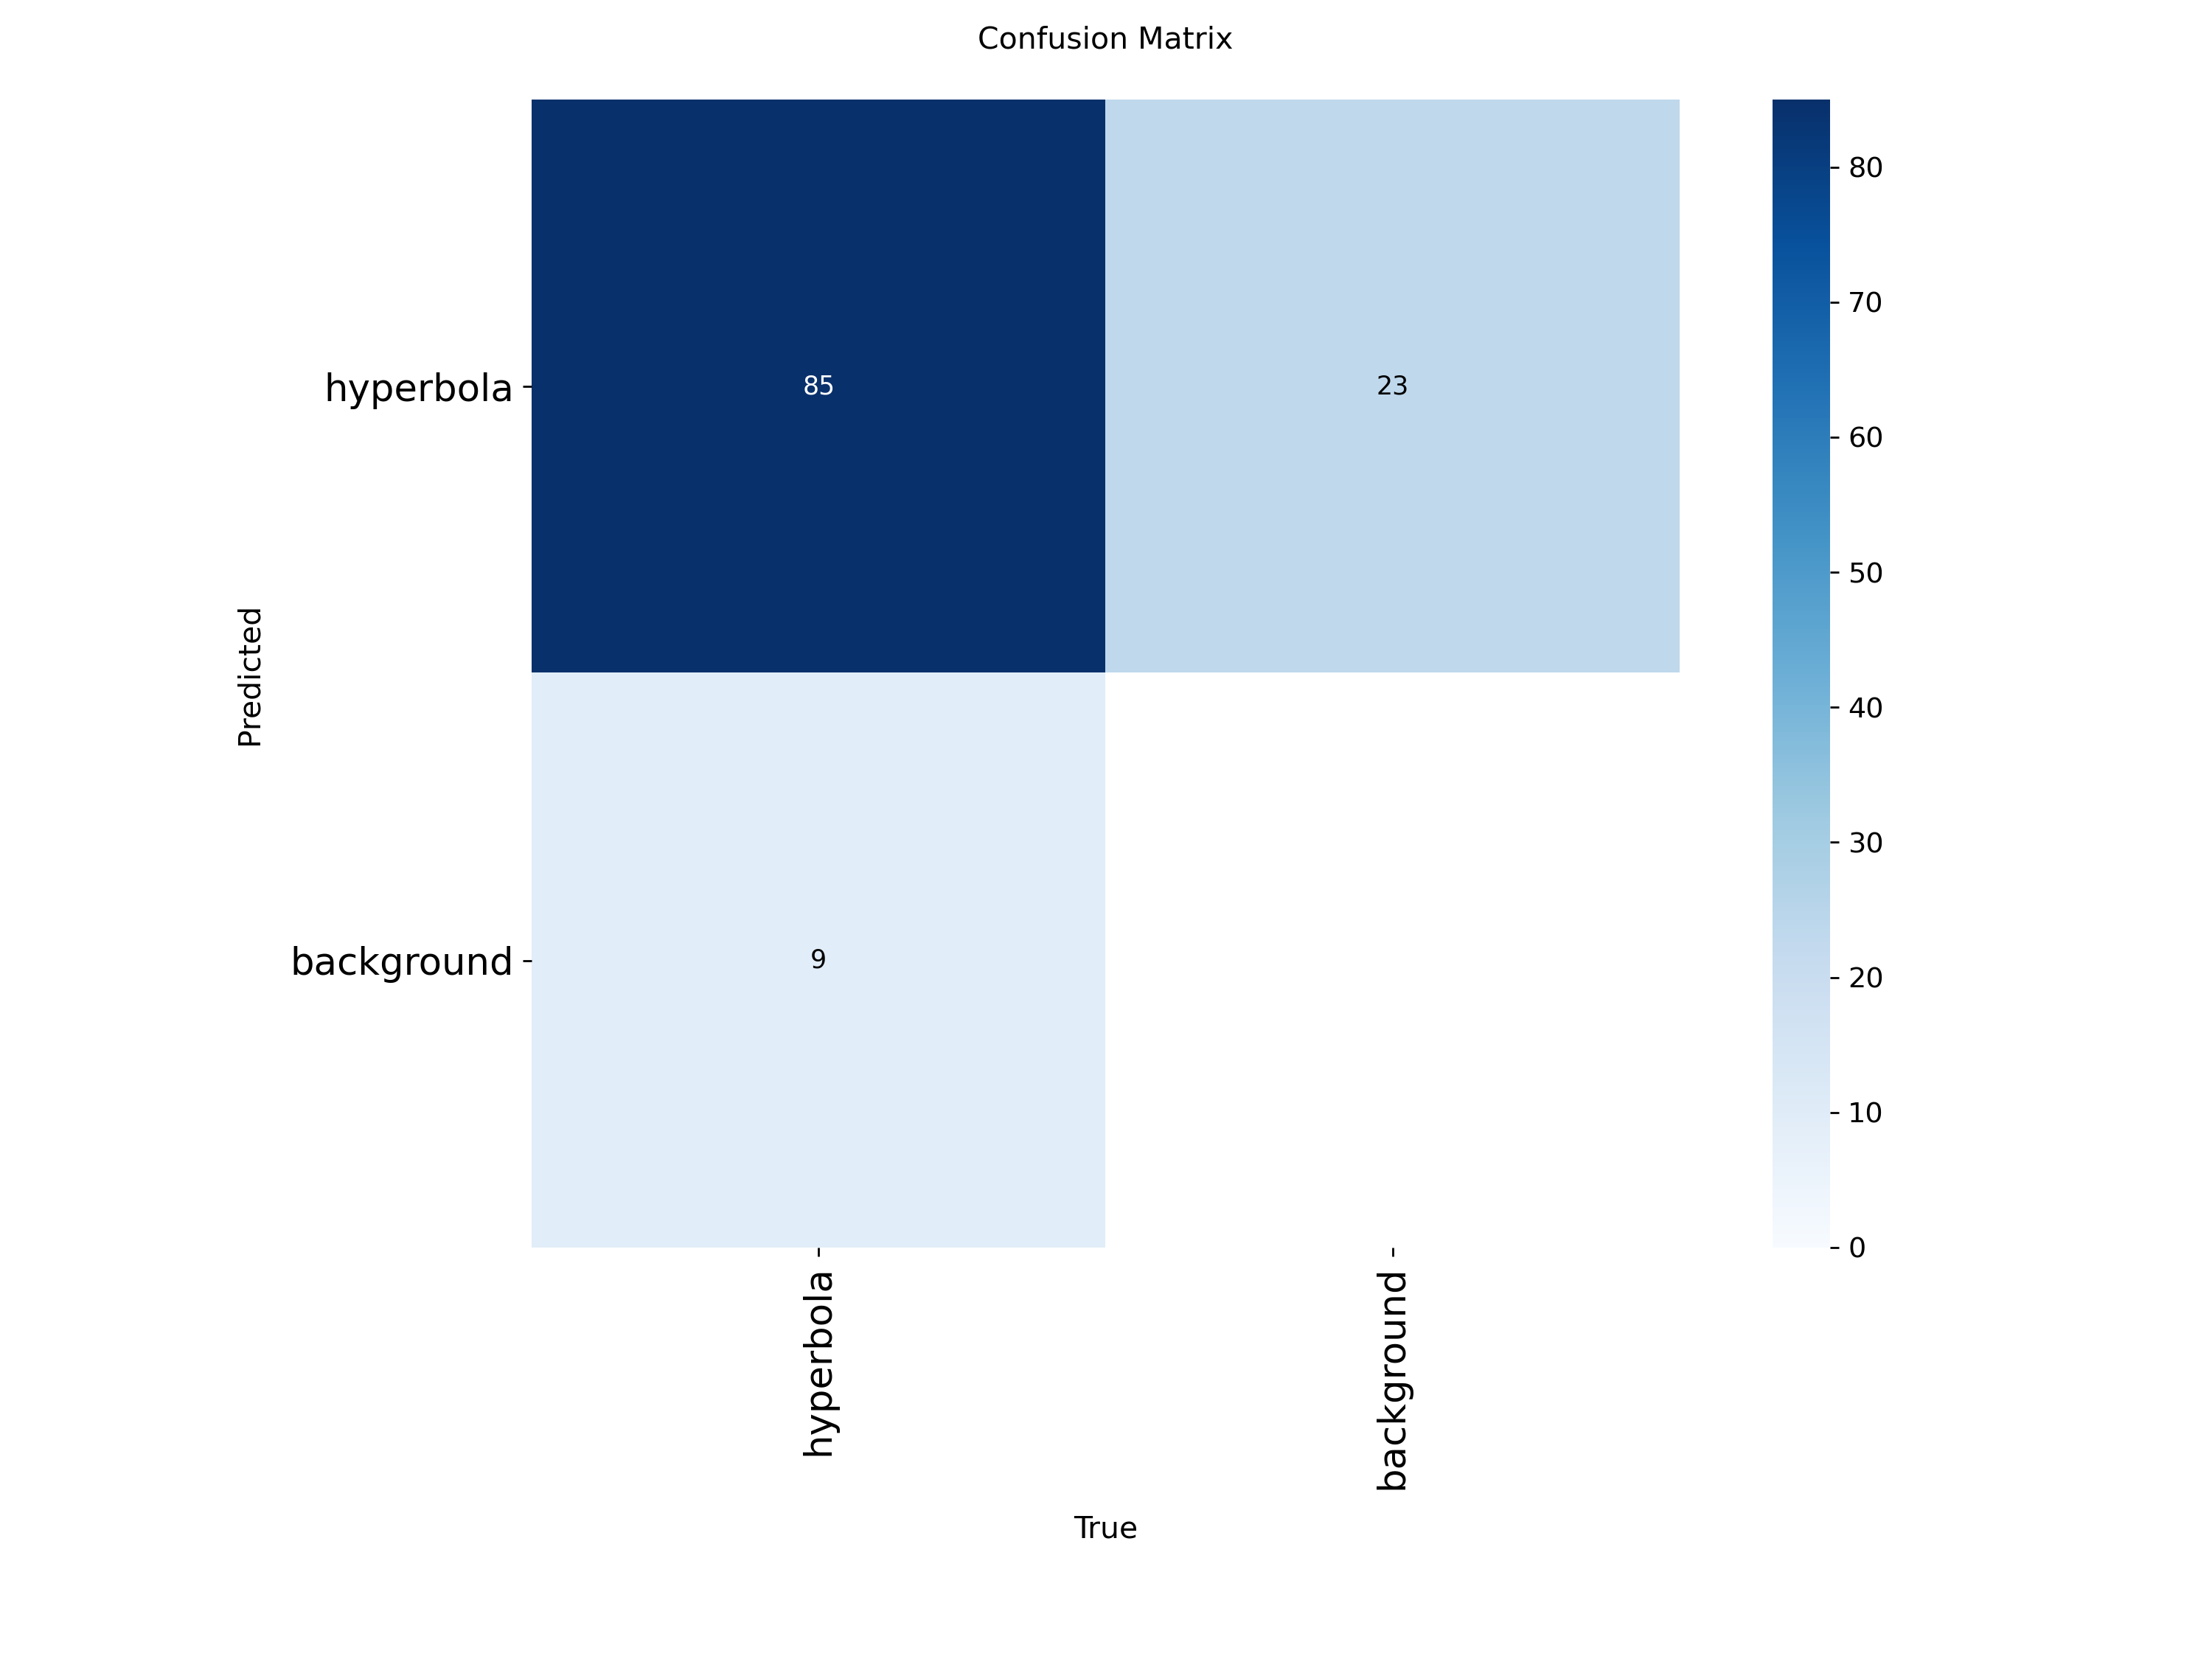

we see that there are 9 False Negatives which influences the Recal negatively. and there are 23 False Positives which influences the Precision negatively

### Chapter 3: Hyperparameter Tuning

Hyperparameter is the Part of the Workflow where the Parameters set for training are getting optimized to get the best performance out of the model. With Yolo there are the following Parameters which can be tuned. Here there has not been done a tuning but should show how it can be done with YOLO.

Table of most common Hyperparameters:
| Hyperparameter     | Description |
|--------------------|-------------|
| epochs             | Number of training epochs used for training. |
| batch              | Batch size for training. |
| imgsz              | Input image size for training and validation. |
| optimizer          | Optimization algorithm used for training (SGD, Adam, AdamW). |
| lr0                | Initial learning rate at the start of training. |
| lrf                | Final learning-rate multiplier (relative to lr0). |
| momentum           | Momentum factor for SGD optimizer. |
| weight_decay       | Strength of L2 regularization to prevent overfitting. |
| warmup_epochs      | Warmup duration in epochs to stabilize early training. |
| warmup_momentum    | Momentum value during warmup. |
| box                | Weight of bounding-box regression loss. |
| cls                | Weight of classification loss. |
| dfl                | Weight of Distribution Focal Loss (YOLOv8+). |
| degrees            | Rotation augmentation in degrees. |
| translate          | Translation augmentation (fraction of image size). |
| scale              | Random image scaling augmentation. |
| shear              | Shear augmentation strength. |
| perspective        | Perspective warping augmentation. |
| fliplr             | Horizontal flip probability. |
| flipud             | Vertical flip probability. |
| mosaic             | Mosaic augmentation probability. |
| mixup              | Mixup augmentation probability. |
| copy_paste         | Copy-Paste augmentation probability (segmentation-focused). |
| hsv_h              | Hue augmentation range. |
| hsv_s              | Saturation augmentation range. |
| hsv_v              | Value (brightness) augmentation range. |





A first step could be just to start a tuning and then validate the model again and to deepdive then which parameters can be even more tuned.

For a first tuning following code could be used

In [ ]:
from ultralytics import YOLO
model = YOLO("") #Load the Model which sgould be tuned
model.tune(
    data="data.yaml", #location to yaml file
    epochs=50,
    imgsz=640,
    optimizer="AdamW"
)

after that the results of the tuning are saved into **runs/tune/**. which includes diffrent plots and a best_hyperparameters.yaml and also a trained model with the best parameters which then again can be validatet and compared to the previous model.
**Note Tuning was not done in this work because of there was not enough time to do that** but it has been shown here how it could be done.